In [1]:
"""
Aim: validation of immune and stallete cells
Author: Yike Xie
Date: 3rd-Apr-2025 
"""

'\nAim: validation of immune and stallete cells\nAuthor: Yike Xie\nDate: 3rd-Apr-2025 \n'

In [2]:
import utils

import scanpy as sc
import anndata as ad

import matplotlib as mpl
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

In [3]:
metadata = pd.read_csv('../tables/DESeq/pseudo_bulk_sum/metadata.tsv', sep='\t', index_col=0)
from matplotlib.patches import Patch

# functions

In [4]:
import gseapy as gp
from gseapy.plot import barplot
import os

def gsea_analysis(genes, path, fn, title):
    res = gp.enrichr(gene_list=genes,
                     gene_sets=['GO_Biological_Process_2023'],
                     organism='Human',
                     cutoff=0.05)
    if fn is not False:
        res.res2d.to_csv(os.path.join(path, fn + '.tsv'), sep='\t')

    barplot(res.res2d, column='Adjusted P-value', Group='Gene_Set',
            size=10, top_term=20, 
            title=title, ofname=os.path.join(path, fn + '.png'),
            cutoff=1.0)
    return res

In [5]:
def gsea_cst_vs_rest(path, adata, obs_col):
    
    for cst in adata.obs[obs_col].unique():
        rank_df = sc.get.rank_genes_groups_df(adata, group=cst)
        g_list = rank_df.head(300)['names'].tolist()

        fn = f'pathways_enriched_in_{cst}_vs_rest'
        title = f'pathways_enriched_in_{cst}_vs_rest'

        res = gsea_analysis(g_list, path, fn, title)

In [6]:
def stacked_barplot_cst_abudance_by_sample(adata, cst_col, metadata, path, cell_type):
    '''
    Example:
    adata: 'acinar',
    cst_col: 'cst1',
    metadata: 'metadata',
    path: '../figures/cst_characterization/Acinar_cells',
    cell_type: 'acinar',
    '''

    color_elements1 = sns.color_palette('Set2')
    color_elements2 = sns.color_palette('husl')

    acinar_abundance2 = adata.obs[[cst_col, 'sample']].groupby([cst_col, 'sample']).size().unstack()
    # only keep samples with more than 0 cells
    acinar_abundance2 = acinar_abundance2[acinar_abundance2.columns[acinar_abundance2.sum(axis=0) > 0]]   
    acinar_abundance_pct_2 = acinar_abundance2 * 100 / acinar_abundance2.sum(axis=0)

    acinar_abundance_pct_2 = acinar_abundance_pct_2[
        metadata.loc[acinar_abundance2.columns]['group'].sort_values().index
    ]

    fig, ax = plt.subplots(figsize=[10, 3])
    acinar_abundance_pct_2.T.plot.bar(stacked=True, ax=ax)

    ax.set_xlabel(None)
    ax.set_ylabel('Proportion [%]')
    ax.legend(bbox_to_anchor=[1, 1])

    ax.set_ylim(0, 120)
    ax.set_xlim(-1, 36)
    
    group_order = sorted(metadata.loc[acinar_abundance2.columns]['group'].unique())
    group_numbers = metadata.loc[acinar_abundance2.columns]['group'].value_counts()
    
    x1 = -0.5
    for i, group in enumerate(group_order):
        x2 = x1 + group_numbers[group]
        ax.plot([x1, x2], [105, 105], c=color_elements2[i])
        ax.plot([x1, x1], [102, 108], c='k')
        ax.text((x1 + x2) / 2, 110, group, va='center', ha='center')
        x1 = x2
        
    ax.plot([x2, x2], [102, 108], c='k')

    acinar_summary = acinar_abundance2.sum()
    label_list = [f"{idx} ({val})" for idx, val in 
                  zip(acinar_summary.index, acinar_summary.values)]

    ax.set_xticks(ax.get_xticks())
    ax.set_xticklabels(label_list)

    fig.savefig(os.path.join(path, f'{cell_type}_cst_abundace_sample.png'), 
                dpi=300, bbox_inches='tight')
    
    return {'fig': fig, 'ax': ax}

In [7]:
def pie_plot_cst_abundace_by_sample(acinar, cst_col, sample, path):
    from matplotlib.patches import Wedge, Patch
    from matplotlib.colors import to_rgba

    # Input data: values (Series), labels (Index), metadata (DataFrame)
    # values = acinar_abundance2['Inflam_acinar_1']
    # labels = acinar_abundance2.index
    # metadata = ...  # must contain 'group' column indexed by labels

    acinar_abundance2 = acinar.obs[[cst_col, sample]].groupby([cst_col, sample]).size().unstack()
    acinar_abundance2 = acinar_abundance2.T  / acinar_abundance2.sum(axis=1)

    for cst in acinar.obs[cst_col].unique():
        values = acinar_abundance2[cst]
        labels = acinar_abundance2.index

        # Match group metadata
        groups = metadata.loc[labels, 'group']

        # Set up group color mapping
        group_color_map = {
            'ND - Lean': 'red',
            'ND - Obese': 'blue',
            'T2D': 'green',
            'T1D': 'orange'
        }

        # Combine everything into a single dataframe and sort
        all_data = pd.DataFrame({
            'value': values,
            'label': labels,
            'group': groups
        }).sort_values(by=['group', 'value'], ascending=[True, False])

        # Generate slice colors: fixed RGB, alpha varies by proportion
        colors = []
        for group in all_data['group'].unique():
            group_data = all_data[all_data['group'] == group]
            base_rgb = to_rgba(group_color_map[group], alpha=1.0)

            # Invert and normalize for alpha scaling (high value = darker)
            val_norm = (group_data['value'] - group_data['value'].min()) / (
                group_data['value'].max() - group_data['value'].min() + 1e-5
            )
            val_alpha = 1.0 - val_norm
            val_alpha = val_alpha.clip(lower=0.2)  # prevent fully transparent

            for alpha in val_alpha:
                colors.append((*base_rgb[:3], alpha))

        # Format labels
        formatted_labels = [f"{label}: {pct:.0%}" 
                            for label, pct in zip(all_data['label'], all_data['value'])]

        # Plot
        fig, ax = plt.subplots(figsize=(10, 10))
        wedges, _ = ax.pie(
            all_data['value'],
            labels=None,
            colors=colors,
            labeldistance=1.15,
            startangle=90
        )

        # Draw outer ring based on group (using wedge angles!)
        for wedge, (_, row) in zip(wedges, all_data.iterrows()):
            ring = Wedge(
                center=(0, 0),
                r=1.05,
                theta1=wedge.theta1,
                theta2=wedge.theta2,
                width=0.07,
                facecolor=group_color_map[row['group']],
                edgecolor='white'
            )
            ax.add_patch(ring)

        # Add labels + connector lines
        for wedge, label in zip(wedges, formatted_labels):
            angle = (wedge.theta2 + wedge.theta1) / 2
            x = np.cos(np.deg2rad(angle))
            y = np.sin(np.deg2rad(angle))

            ax.text(
                1.15 * x, 1.15 * y, label,
                ha='left' if x > 0 else 'right',
                va='center',
                fontsize=8
            )
            ax.plot([0.9 * x, 1.1 * x], [0.9 * y, 1.1 * y], color='gray', lw=0.8)

        # Add legend
        legend_elements = [
            Patch(facecolor=color, label=group)
            for group, color in group_color_map.items()
        ]
        ax.legend(
            handles=legend_elements,
            title="Group",
            loc='center left',
            bbox_to_anchor=(1.05, 0.5),
            fontsize=9
        )

        # Finalize plot
        ax.set_title(f"{cst} Proportions by Patient Group", fontsize=13)
        ax.axis('equal')
        plt.tight_layout()
        plt.show()

        fig.savefig(os.path.join(path, f'pie_{cst}_abundance_by_donor.png'), 
                    dpi=300, bbox_inches='tight')

In [8]:
def clustermap_maker_genes(adata, obs_col, marker_genes, path, fdn, **kwargs):
    '''
    adata: adata,
    obs_col: 'cst1',
    marker_genes: marker_genes,
    '''
    adata_tmp = adata[:, marker_genes].copy()
    groups = adata_tmp.obs[obs_col].cat.categories
    
    ave_exp = pd.DataFrame([], index=marker_genes, columns=groups)
    
    for col in ave_exp.columns:
        ave_exp[col] = np.asarray(adata_tmp[adata_tmp.obs[obs_col] == col].X.mean(axis=0))[0]

    g = sns.clustermap(ave_exp.T, cbar_pos=(0.02, 0.02, 0.02, 0.18),
                       figsize=[1 + len(marker_genes) * 0.3, 1 + len(groups) * 0.3], 
                       dendrogram_ratio=0.1, **kwargs)
    
    g.fig.savefig(os.path.join(path, fdn), dpi=300, bbox_inches='tight')
    
    return g

# load data

In [9]:
# load data
adata = sc.read_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')
adata.raw = adata

In [10]:
utils.normalizedata(adata, log1p=True)

AnnData object with n_obs × n_vars = 57935 × 38560
    obs: 'sample', 'doublet_score', 'Sex', 'BMI', 'T1D', 'Diabetes Duration', 'T2D', 'HbA1c (%)', 'HbA1c', 'Age', 'CIT (hours)', 'Cohort', 'RIN', 'Nuclei isolation', 'group', 'cell_type', 'cell_subtype', 'cst1', 'cst2'
    var: 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cst1_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'

# Immune cells

In [11]:
immune = adata[adata.obs['cell_type'] == 'Immune']

## Frederik

| Cell Type         | Core Function                              |
|-------------------|---------------------------------------------|
| Naive B cell      | Waits to encounter antigen                  |
| Activated B cell  | Proliferates, can class-switch              |
| Memory B cell     | Long-lived, antigen-experienced             |
| Plasmablast       | Activated B cell transitioning to plasma    |
| Plasma cell       | Dedicated antibody factory                  |


| Feature                      | B Cells                          | Plasmablasts                          | Plasma Cells                        |
|-----------------------------|----------------------------------|---------------------------------------|-------------------------------------|
| **Main role**               | Antigen recognition, memory      | Transition to plasma cell, antibody secretion | Long-lived antibody production     |
| **Proliferation**           | ✅ Can proliferate                | ✅ Actively proliferating              | ❌ Generally non-proliferative      |
| **Immunoglobulin type**     | Membrane-bound IgM/IgD, some IgG/IgA | Secreted IgG, IgA, IgM               | Secreted IgG, IgA, IgM              |
| **CD19**                    | ✅ High                          | ✅ Often high                          | ❌ Low or absent                    |
| **CD20 (MS4A1)**            | ✅ High                          | ❌ Low                                | ❌ Absent                           |
| **CD27**                    | ✅ (memory B cells)              | ✅ Often high                          | ❌ Often low                        |
| **CD38**                    | ❌ Low                           | ✅ High                                | ✅ Very high                        |
| **CD138 (SDC1)**            | ❌ Absent                        | ❌ Absent or low                       | ✅ High                             |
| **CD79A / CD79B**           | ✅ High                          | ✅ Often moderate                      | ❌ Absent                           |
| **JCHAIN**                  | ❌ Low                           | ✅ Moderate                            | ✅ High                             |
| **PRDM1 (BLIMP1)**          | ❌ Absent                        | ✅ High                                | ✅ High                             |
| **XBP1**                    | ❌ Absent                        | ✅ High                                | ✅ High                             |
| **MZB1**                    | ❌ Absent                        | ❌ Low                                | ✅ High                             |
| **Antigen presentation (MHC II)** | ✅ Active                  | ✅ Lower                               | ❌ Suppressed                       |
| **Location**                | Lymph nodes, spleen, blood       | Blood, secondary lymphoid tissues     | Bone marrow, mucosa, inflamed tissue |


| Marker                    | Expression | What it suggests                                   |
|---------------------------|------------|----------------------------------------------------|
| IL7R, CD247, TOX          | ✅ High     | Memory/quiescent T-lineage identity                |
| CD4, CD8A, SELL, CD69     | ❌ Low      | Not naive, not T<sub>RM</sub>, not recirculating   |
| MKI67, GZMA, ENTPD1       | ❌ Low      | Not proliferative, not cytotoxic or exhausted      |


In [132]:
marker_genes = [
#     "FOXP1", "BCL2",  # quiescent memory/naive survival
    "TOX",  # Quiescence/developmental programming 
    "CD247",  # T cell lineage
    "IL7R", # naive or memory T cells
    "CD3D", # "CD3E", "CD3G",  # low expression, suggests quiescence
    "CD4", "CD8A",  # confirm absence of lineage commitment
    "PDCD1", # "CTLA4", "ENTPD1",  # exhaustion markers
    "ID2", # "TBX21", "RORC", "GATA3",  # low = not ILCs (“T-like” innate cells)
    'SELL', # naive / central memory T cells
    "CD69", # tissue-resident memory T cells
    "GZMA", # CD8+ effector T cells
    'MKI67', #'PCNA', 'TOP2A', # proliferative markers (confirm quiescence)
    
    'CD163', # macrophage marker
    'F13A1', # tissue resident macrophages
    'ITGAX', # Inflammatory / activated macrophages and DCs
    'HLA-DRB1', # MHC II genes
    'CD14', # optional: 'CD68', 'LYZ', # Monocyte/infiltrating macrophage markers
    
    'CD38',  # plsamablasts and plasma cells
    'IGHA1', 'IGHG1', 'IGHM', # Immunoglobulin isotypes
    "PRDM1", "XBP1", "JCHAIN", # Core antibody-secreting transcriptional program
    "SDC1" ,"MZB1",  # plasma cell markers, low in plasmablasts
    "CD27", # usually high in plasmablsts, maybe downregulated in some mucosal plasmablasts and certain IgA⁺ cells
    'CD79A', 'MS4A1', # B cell markers, low in plasmablasts
    
    "IL1RL1", 'KIT', # mast cells
    
    'NRXN3', # Neuron cells
                ]
# scale on these genes
immune_show = immune[:, marker_genes].copy()
sc.pp.scale(immune_show, zero_center=False)

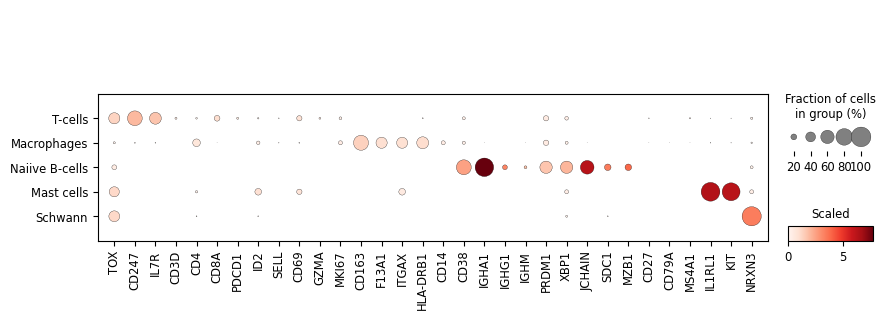

In [135]:
fig, ax = plt.subplots(figsize=[10, 3])
sc.pl.dotplot(immune_show, 
              var_names = marker_genes, 
              groupby = 'cell_subtype',
              color_map='Reds',
              colorbar_title = 'Scaled',
              use_raw=False,      
              categories_order=[
                  'T-cells', 
                  'Macrophages', 
                  'Naiive B-cells', 
                  'Mast cells', 
                  'Schwann'],
              ax=ax
              )

1. macrophages --> Pancreatic_resident_macrophages 
    - I can't distinguish inflammatory or non-inflammatory
    - Cells that are anchored in tissue, self-renew locally, and do not recirculate
2. naive B-cells --> CD27-_IgA+_plasmablasts
3. T-cells --> Pancreatic_persistent_memory_like_T_cells 
    - stay in tissue long-term, but may not be fully locked in
4. Schwann --> Neurons

## save the annotation to adata

In [105]:
# load adata's raw data first
adata = sc.read_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')

# change the cell_type of schwann as neurons
adata.obs['cell_type'] = adata.obs['cell_type'].cat.add_categories(['Neurons'])
adata.obs.loc[adata.obs['cell_subtype'] =='Schwann', 'cell_type'] = 'Neurons'

# add the new subtype annotation into adata
for obs_col in ['cst1', 'cst2']:
    immune.obs[obs_col] = pd.Series([None] * immune.n_obs, dtype='object')
    immune.obs.loc[immune.obs['cell_subtype'] == 'Macrophages', obs_col] = 'Pancreatic_resident_macrophages'
    immune.obs.loc[immune.obs['cell_subtype'] == 'Naiive B-cells', obs_col] = 'CD27-_IgA+_plasmablasts'
    immune.obs.loc[immune.obs['cell_subtype'] == 'T-cells', obs_col] = 'Pancreatic_persistent_memory_like_T_cells'
    immune.obs.loc[immune.obs['cell_subtype'] == 'Mast cells', obs_col] = 'Mast_cells'
    immune.obs.loc[immune.obs['cell_subtype'] == 'Schwann', obs_col] = 'Neurons'
    
    adata.obs[obs_col] = adata.obs[obs_col].cat.add_categories([
        'Pancreatic_resident_macrophages',
        'CD27-_IgA+_plasmablasts',
        'Pancreatic_persistent_memory_like_T_cells',
        'Mast_cells',
        'Neurons',
    ])

    adata.obs.loc[immune.obs.index, obs_col] = immune.obs[obs_col]
    adata.obs[obs_col] = adata.obs[obs_col].cat.remove_unused_categories()

# save the annotation
adata.write_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')

## make plots

In [143]:
immune_new = immune_show[~ (immune_show.obs['cst1'] == 'Neurons')].copy()

immune_new.obs['cst1'] = immune_new.obs['cst1'].astype('category')
immune_new.obs['cst2'] = immune_new.obs['cst2'].astype('category')

In [138]:
marker_genes = [
#     "FOXP1", "BCL2",  # quiescent memory/naive survival
    "TOX",  # Quiescence/developmental programming 
    "CD247",  # T cell lineage
    "IL7R", # naive or memory T cells
    "CD3D", # "CD3E", "CD3G",  # low expression, suggests quiescence
    "CD4", "CD8A",  # confirm absence of lineage commitment
    "PDCD1", # "CTLA4", "ENTPD1",  # exhaustion markers
    "ID2", # "TBX21", "RORC", "GATA3",  # low = not ILCs (“T-like” innate cells)
    'SELL', # naive / central memory T cells
    "CD69", # tissue-resident memory T cells
    "GZMA", # CD8+ effector T cells
    'MKI67', #'PCNA', 'TOP2A', # proliferative markers (confirm quiescence)
    
    'CD163', # macrophage marker
    'F13A1', # tissue resident macrophages
    'ITGAX', # Inflammatory / activated macrophages and DCs
    'HLA-DRB1', # MHC II genes
    'CD14', # optional: 'CD68', 'LYZ', # Monocyte/infiltrating macrophage markers
    
    'CD38',  # plsamablasts and plasma cells
    'IGHA1', 'IGHG1', 'IGHM', # Immunoglobulin isotypes
    "PRDM1", "XBP1", "JCHAIN", # Core antibody-secreting transcriptional program
    "SDC1" ,"MZB1",  # plasma cell markers, low in plasmablasts
    "CD27", # usually high in plasmablsts, maybe downregulated in some mucosal plasmablasts and certain IgA⁺ cells
    'CD79A', 'MS4A1', # B cell markers, low in plasmablasts
    
    "IL1RL1", 'KIT', # mast cells
                ]
# scale on these genes
immune_show = immune[:, marker_genes].copy()
sc.pp.scale(immune_show, zero_center=False)

/home/yike/.conda/envs/scanpy/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/yike/.conda/envs/scanpy/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


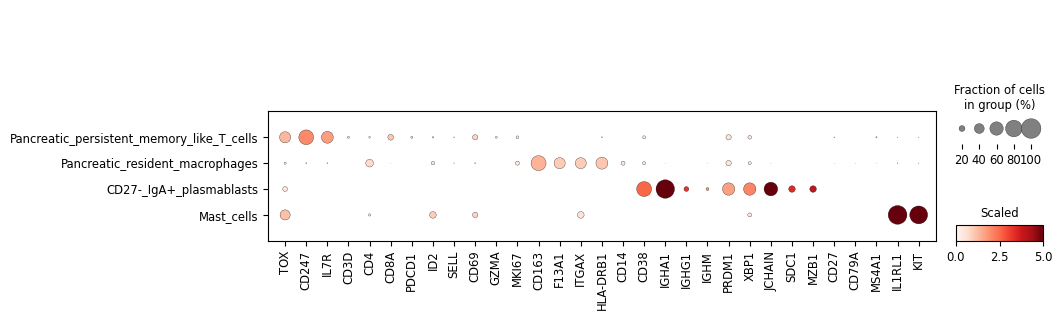

In [141]:
fig, ax = plt.subplots(figsize=[10, 3])
sc.pl.dotplot(immune_new, 
              var_names=marker_genes, 
              groupby='cst1',
              color_map='Reds',
              colorbar_title='Scaled',
              use_raw=False,      
              categories_order=[
                  'Pancreatic_persistent_memory_like_T_cells',
                  'Pancreatic_resident_macrophages',
                  'CD27-_IgA+_plasmablasts',
                  'Mast_cells'],
              ax=ax, vmax=5
              )
fig.savefig('../figures/cst_characterization/Immune_cells/otplot_immune_cells.png', 
            dpi=300, bbox_inches='tight')

/home/yike/.conda/envs/scanpy/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c
/home/yike/.conda/envs/scanpy/lib/python3.12/site-packages/anndata/_core/anndata.py:1146: ImplicitModificationWarning: Trying to modify attribute `.obs` of view, initializing view as actual.
  df[key] = c


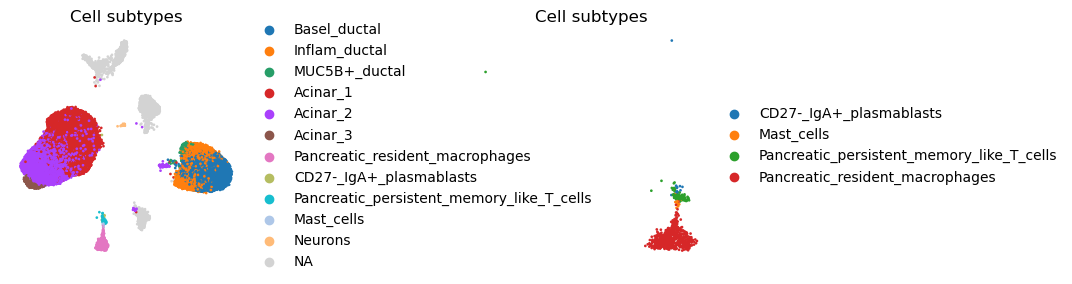

In [142]:
fig, axs = plt.subplots(1, 2, figsize=[9, 3])
plt.subplots_adjust(wspace=1)
sc.pl.umap(adata, color='cst1', ax=axs[0], size=15, show=False,  frameon = False)
axs[0].set_title('Cell subtypes')
sc.pl.umap(immune_new, color='cst1', ax=axs[1], size=15, show=False,  frameon = False)
axs[1].set_title('Cell subtypes')
fig.savefig('../figures/cst_characterization/Immune_cells/adata_UMAP.png', 
            dpi=300, bbox_inches='tight')

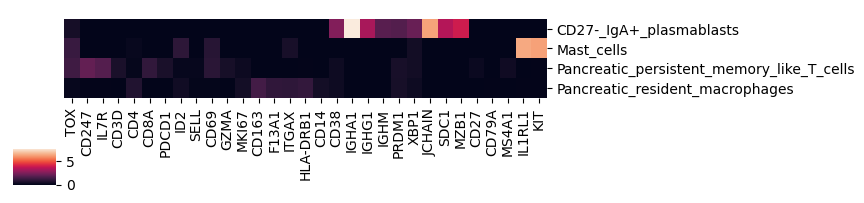

In [174]:
path = '../figures/cst_characterization/Immune_cells/'
clustermap_maker_genes(immune_new, 'cst1', marker_genes, path, 'heatmap_immune_marker_genes.png', 
                       col_cluster=False, 
                       row_cluster=False,
                      )

/tmp/ipykernel_7473/3558575067.py:13: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acinar_abundance2 = adata.obs[[obs_col, sample]].groupby([obs_col, sample]).size().unstack()


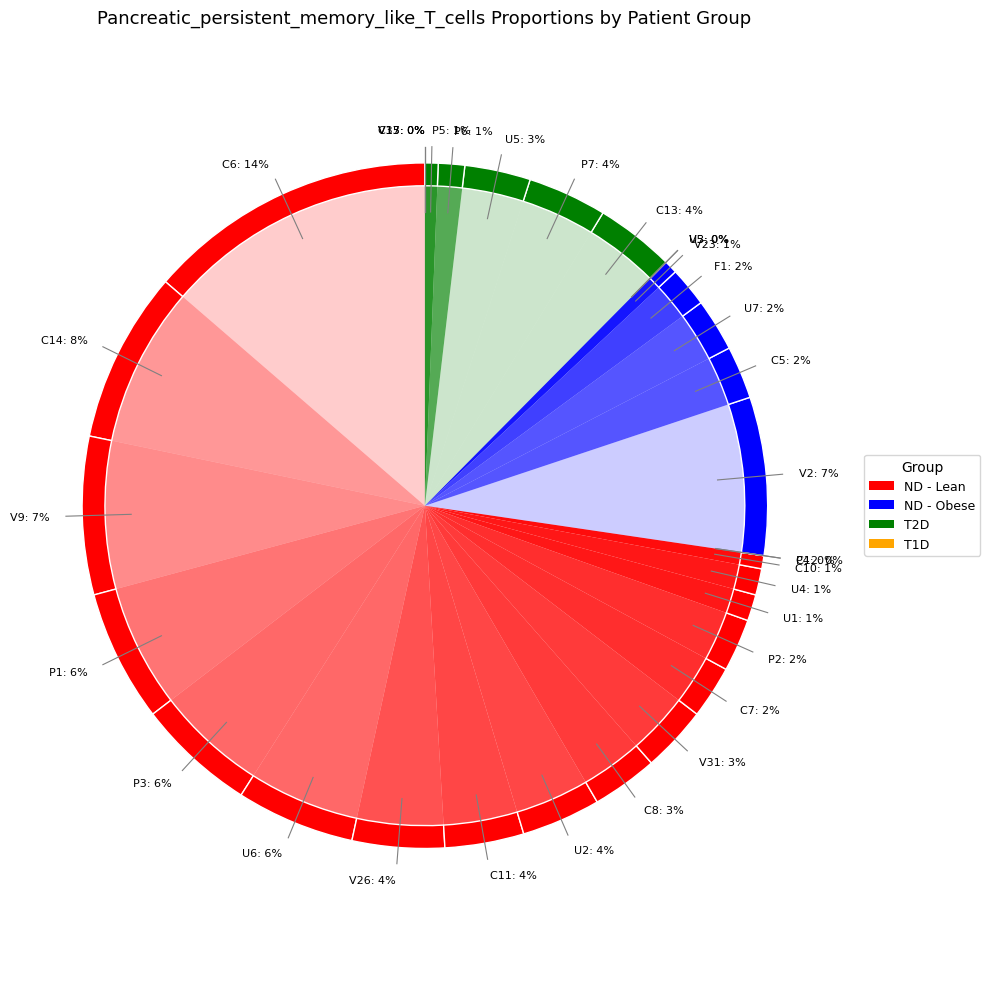

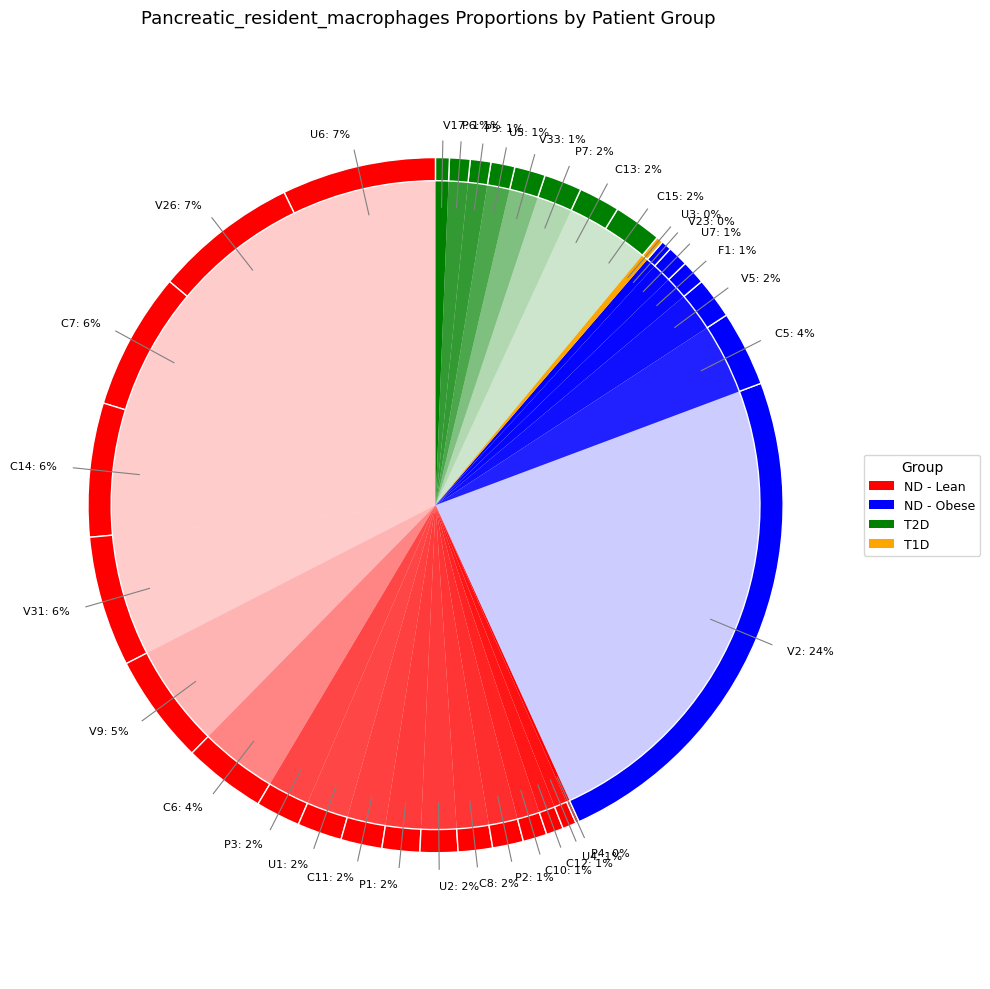

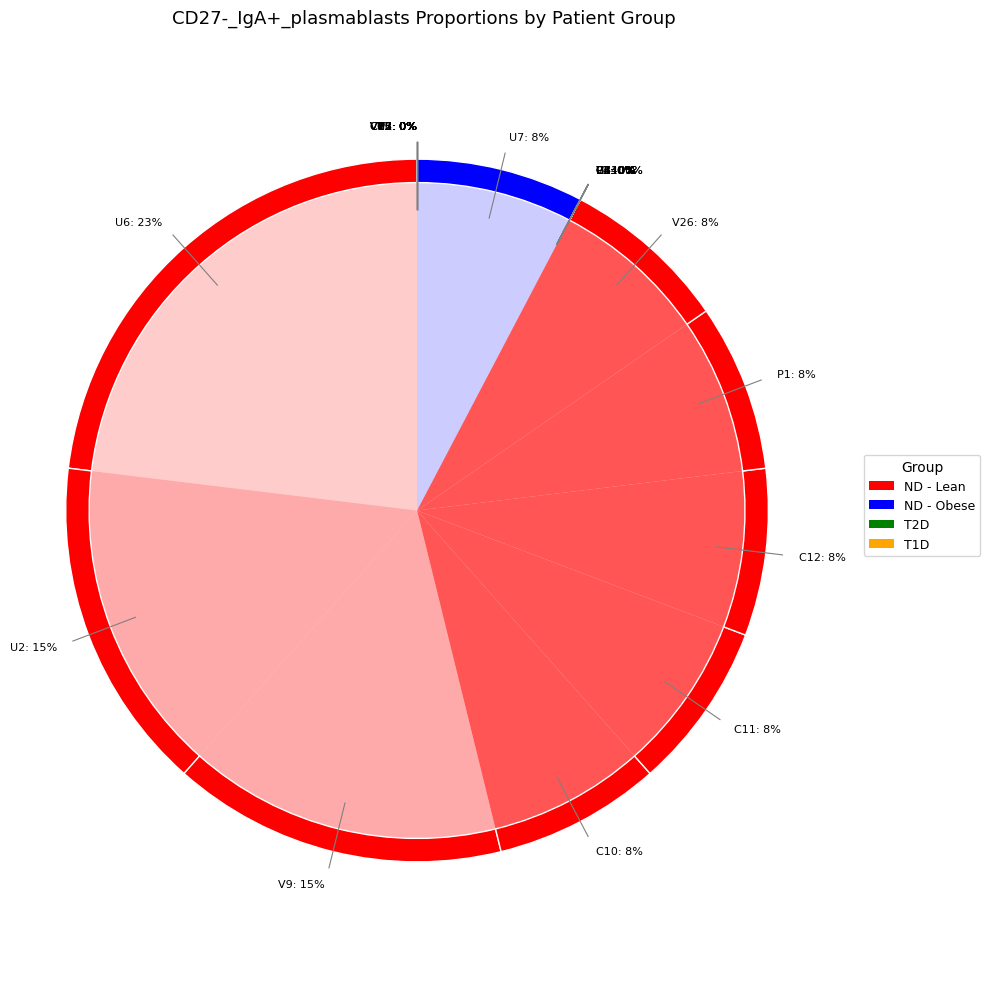

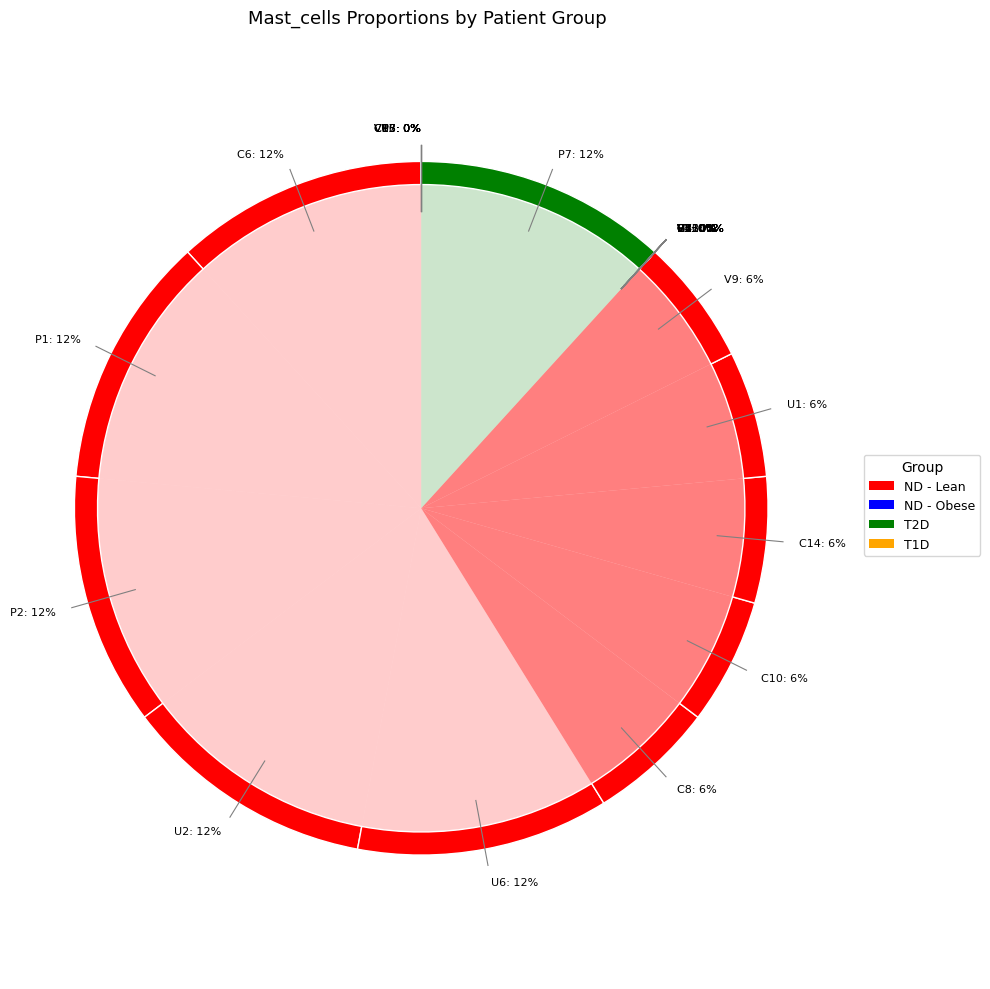

In [180]:
pie_plot_cst_abundace_by_sample(immune_new, 'cst1', 'sample', path)

/tmp/ipykernel_2825/1999673198.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acinar_abundance2 = adata.obs[[cst_col, 'sample']].groupby([cst_col, 'sample']).size().unstack()


{'fig': <Figure size 1000x300 with 1 Axes>,
 'ax': <Axes: ylabel='Proportion [%]'>}

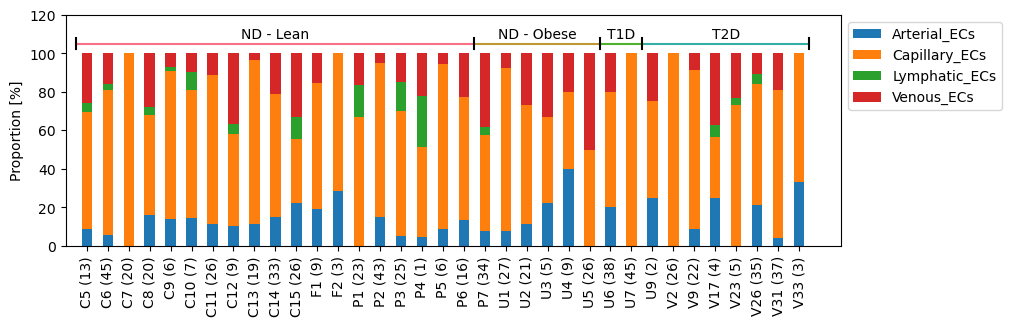

In [102]:
stacked_barplot_cst_abudance_by_sample(immune_new, 'cst1', metadata, path, 'Immune')

Similarities between mast cells and acinar cells

| Feature              | Mast cells                                                    | Acinar cells (pancreatic)                                |
|----------------------|----------------------------------------------------------------|------------------------------------------------------------|
| 🔬 Vesicles/granules | Yes — secretory granules with histamine, proteases, cytokines | Yes — zymogen granules storing digestive enzymes           |
| ⚡ Rapid release     | Yes — degranulate upon IgE/allergen or cytokine stimulation   | Yes — release enzymes upon neurohormonal stimulation       |
| 🏭 Secretory machinery | SNAREs, RABs, synaptotagmins involved                         | Similar machinery with acinar-specific adaptations         |
| 🧪 Stored vs synthesized | Mostly pre-formed mediators + some new synthesis             | Enzymes are synthesized & stored until needed              |
| 💥 Trigger sensitivity | Allergens, IgE, cytokines                                     | Cholecystokinin, vagal ACh, intracellular Ca²⁺ signaling   |


Difference between mast cells and acinar cells

| Aspect               | Mast cells                                  | Acinar cells                                      |
|----------------------|----------------------------------------------|---------------------------------------------------|
| Function             | Immune defense, allergy, inflammation        | Digestion — enzyme secretion into ducts           |
| Origin               | Hematopoietic (myeloid lineage)              | Epithelial (endoderm-derived)                     |
| Secreted products    | Histamine, tryptase, cytokines, prostaglandins | Trypsinogen, amylase, lipase, etc.              |
| Granule markers      | TPSAB1, CPA3, HDC, KIT, IL1RL1               | PRSS1, CPA1, AMY2A, CTRB2, CEL                    |
| Localization         | Mucosa, skin, connective tissue              | Pancreas (also salivary glands for similar cells) |


# Endothelial cells

In [10]:
endo = adata[adata.obs['cell_type'] == 'Endothelial']

In [11]:
batch_label = 'sample'
neighbors_within_batch = 1

sc.pp.highly_variable_genes(endo, n_top_genes=2000) 
print('PCA')
sc.tl.pca(endo) # n_comps default is 50
print('Infer neighbors')
sc.pp.neighbors(endo, n_pcs=40)
print('# Run BBKNN to correct batch effects by aligning neighbors across batches')
sc.external.pp.bbknn(endo, batch_key=batch_label, 
                     neighbors_within_batch=neighbors_within_batch)  
print('Run UMAP')
sc.tl.umap(endo)
print('Find communities')

/home/yike/.conda/envs/scanpy/lib/python3.12/site-packages/scanpy/preprocessing/_highly_variable_genes.py:696: ImplicitModificationWarning: Trying to modify attribute `._uns` of view, initializing view as actual.
  adata.uns["hvg"] = {"flavor": flavor}


PCA
Infer neighbors


/home/yike/.conda/envs/scanpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Run BBKNN to correct batch effects by aligning neighbors across batches
Run UMAP
Find communities


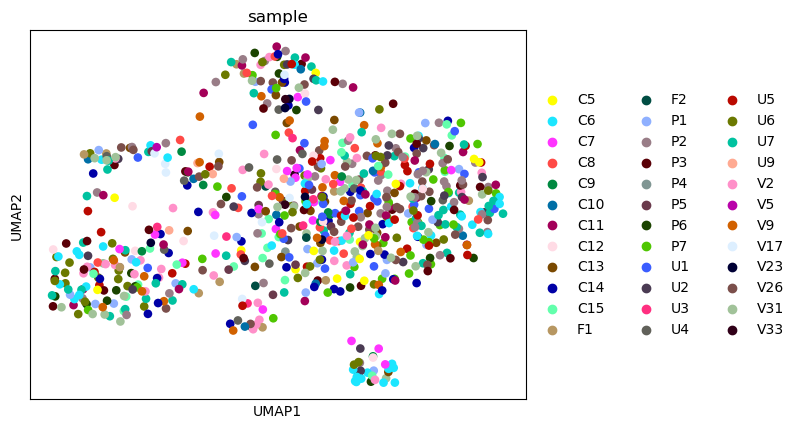

In [12]:
sc.pl.umap(endo, color='sample') 

In [13]:
resolution = 1.2
sc.tl.leiden(endo, flavor="igraph", n_iterations=2, 
             resolution=resolution, key_added=f"leiden_r{resolution}")

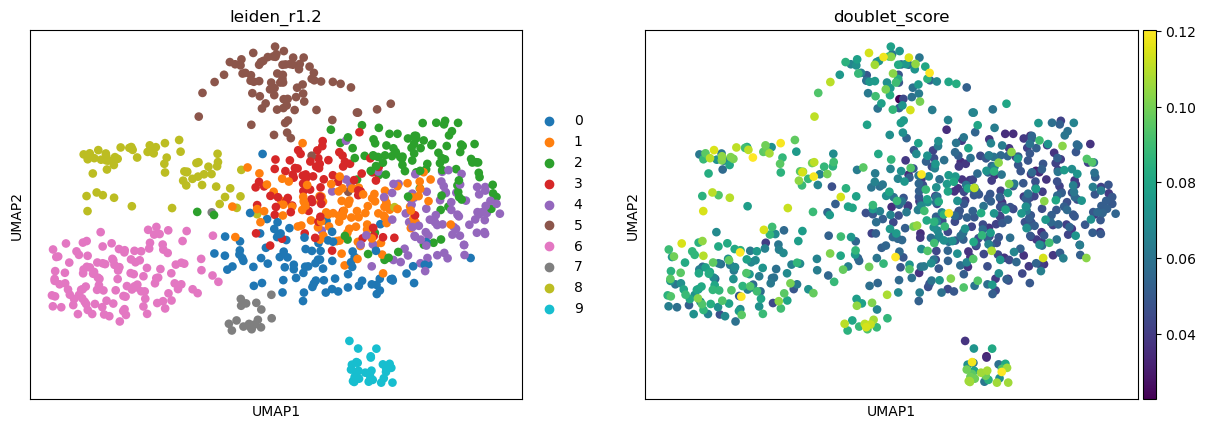

In [14]:
sc.pl.umap(endo, color=['leiden_r1.2', 'doublet_score'],)

In [15]:
sc.tl.rank_genes_groups(endo, groupby='leiden_r1.2', use_raw=False)

In [93]:
sc.get.rank_genes_groups_df(endo, group='0')

,names,scores,logfoldchanges,pvals,pvals_adj
0,PCDH17,9.705751,4.946863,1.599396e-16,8.810385e-13
1,PLCB1,7.141912,1.599281,2.515030e-11,3.292553e-08
2,CEMIP2,6.534006,3.650478,2.084262e-09,1.409985e-06
3,COL15A1,5.880133,2.982029,3.808070e-08,1.689339e-05
4,ADAMTS9,5.841122,3.276123,4.852120e-08,2.011804e-05
...,...,...,...,...,...
38555,PRDM16,-9.073655,-4.869718,2.869954e-18,2.323960e-14
38556,NALF1,-9.136515,-4.526502,1.266804e-17,8.141328e-14
38557,CPE,-9.302445,-29.979469,1.827284e-19,2.348669e-15
38558,SULF1,-10.631685,-30.533171,1.553971e-24,2.996057e-20


In [67]:
sc.get.rank_genes_groups_df(endo, group='5')

,names,scores,logfoldchanges,pvals,pvals_adj
0,PCSK5,18.486673,9.318607,7.562797e-32,2.083010e-28
1,ARL15,14.192828,4.503089,2.854550e-29,6.879466e-26
2,PRDM16,12.141480,7.363207,4.103077e-20,3.955366e-17
3,PLCB4,10.443532,5.906043,1.969769e-17,1.433100e-14
4,VEGFC,9.676066,6.347953,2.538683e-15,1.461069e-12
...,...,...,...,...,...
38555,VAV3,-16.468868,-6.562979,1.675236e-46,1.291942e-42
38556,PDE2A,-16.816143,-6.989817,1.848286e-51,2.375664e-47
38557,COL15A1,-17.756134,-7.284485,6.809041e-40,3.750809e-36
38558,NEURL1B,-18.936724,-32.862289,9.052044e-65,1.745234e-60


In [68]:
sc.get.rank_genes_groups_df(endo, group='6')

,names,scores,logfoldchanges,pvals,pvals_adj
0,NALF1,34.563171,11.314139,1.724752e-79,2.216881e-75
1,ZNF385D,26.053980,7.211483,4.111106e-92,7.926213e-88
2,TLL1,24.709015,9.319969,4.116958e-57,3.968747e-53
3,LINC02147,22.556751,9.598996,1.018176e-50,7.852174e-47
4,TSHZ2,15.944622,6.756285,4.514498e-37,2.486844e-33
...,...,...,...,...,...
38555,KDR,-13.439425,-5.084213,1.461430e-32,5.122976e-29
38556,CD36,-13.975487,-5.802355,4.660423e-33,1.797059e-29
38557,ADGRF5,-14.689021,-5.561845,6.805359e-36,3.280183e-32
38558,LNX1,-16.473932,-6.092582,3.443866e-45,2.213258e-41


In [51]:
sc.get.rank_genes_groups_df(endo, group='7')

,names,scores,logfoldchanges,pvals,pvals_adj
0,BICC1,45.910671,10.388600,5.426087e-35,4.184598e-31
1,PKHD1,39.103405,10.563294,2.075360e-26,3.077919e-23
2,CFTR,36.354794,9.860227,7.995445e-31,3.425604e-27
3,GLIS3,35.059769,8.948501,9.422912e-33,4.541843e-29
4,ESRRG,32.533386,10.244366,7.235284e-21,5.072592e-18
...,...,...,...,...,...
38555,TNFSF10,-12.750469,-30.810061,7.442803e-34,4.783241e-30
38556,CNTNAP3B,-13.563062,-31.095783,1.189858e-37,1.147023e-33
38557,CAVIN2,-13.749709,-31.173088,1.526042e-38,1.961473e-34
38558,PPM1F,-14.647901,-31.376333,6.221253e-43,1.199458e-38


In [48]:
sc.get.rank_genes_groups_df(endo, group='8')

,names,scores,logfoldchanges,pvals,pvals_adj
0,CPA1,21.853249,7.772991,1.296886e-40,1.666931e-36
1,CPB1,21.363245,6.618859,1.639626e-45,6.322399e-41
2,GP2,20.315077,6.144396,1.867702e-43,3.600930e-39
3,PNLIPRP2,18.059240,7.859294,8.058516e-31,7.768410e-27
4,CEL,17.845102,8.181274,2.323790e-29,1.792107e-25
...,...,...,...,...,...
38555,ENSG00000204003,-6.809341,-28.694075,2.098666e-11,2.023114e-08
38556,GUCY1A1,-6.937489,-28.826361,9.039151e-12,9.420261e-09
38557,DLGAP1,-7.282363,-29.131069,8.780353e-13,1.092163e-09
38558,LRRC49,-7.891568,-29.197094,1.139145e-14,1.996611e-11


In [55]:
sc.get.rank_genes_groups_df(endo, group='9')

,names,scores,logfoldchanges,pvals,pvals_adj
0,PKHD1L1,23.693161,14.282062,2.596191e-20,3.763501e-18
1,PPFIBP1,22.106524,5.242839,7.143140e-41,3.722155e-38
2,RELN,14.965599,15.279357,6.745723e-15,5.090315e-13
3,PGM5,12.648380,7.678710,4.580453e-14,3.082413e-12
4,EFNA5,12.459960,13.016734,5.712772e-13,3.307575e-11
...,...,...,...,...,...
38555,COL15A1,-33.710747,-36.100559,8.290505e-152,6.393637e-148
38556,NOTCH4,-34.416553,-35.695927,6.957755e-156,6.707276e-152
38557,ADGRL4,-37.529957,-36.117130,1.276636e-173,1.640903e-169
38558,PDE10A,-41.271591,-36.934566,2.457920e-194,4.738870e-190


In [18]:
marker_genes = [
    'PECAM1', # marker gene
    'GJA5', 'DLL4', # arterial
    'NR2F2', 'EPHB4', 'NPR3', # venous
    'PLVAP', 'CD36', 'CA4', # capillary
    'PROX1', 'LYVE1','FLT4', # lymphatic
#     'PCDH17', # neuronal or neuroendorine
#     'PRDM16', # stromal/fibroblats
#     #'PLCB4', 
#     'ZNF385D', # Islet endocrine 
#     'TLL1', # Stromal / fibroblast / vascular-associated cells, eg pericytes or vascular adventitia
    'BICC1', 'CFTR', # epithelial cells -- ducts
    'PRSS1', 'CPA1', 'CPA2', # acinar cells
    
#     'PKHD1L1', # ductal epithelial
#     'RELN', # Islet/endocrine/neuronal
#     'PGM5', # Stromal/pericyte/smooth muscle
#     'EFNA5' # EC-associated, but also neuronal/epithelial
]

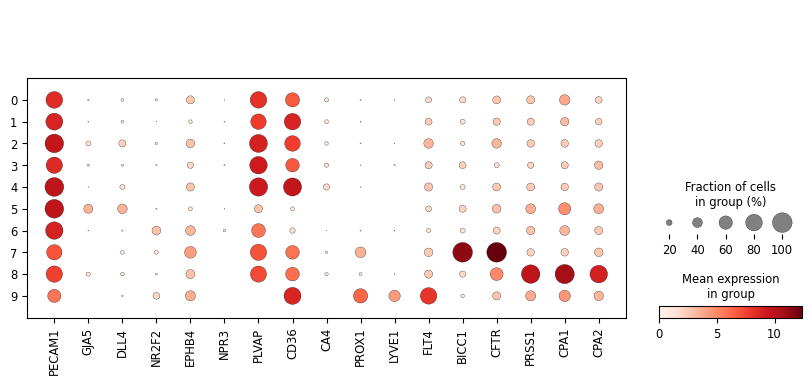

In [19]:
fig, ax = plt.subplots(figsize=[10, 4])
sc.pl.dotplot(endo, 
              var_names=marker_genes, 
              groupby=f"leiden_r1.2",
              color_map='Reds', 
              ax=ax,
              use_raw=False
         )

In [20]:
'''
Arterial: 5,
Venous: 6,
Capillary: 0, 1, 2, 3, 4,
doublets (ECs and ductal cells): 7 --> 18
doublets (ECs and acinar cells): 8 --> 65
Lymphatic: 9
'''

'\nArterial: 5,\nVenous: 6,\nCapillary: 0, 1, 2, 3, 4,\ndoublets (ECs and ductal epithelial): 7\ndoublets (ECs and acinar cells): 8\nLymphatic: 9\n'

In [23]:
endo.obs['leiden_r1.2'].value_counts()

leiden_r1.2
6    128
1    105
2     97
0     88
4     87
5     78
3     77
8     65
9     29
7     18
Name: count, dtype: int64

In [21]:
endo.obs['cst1'] = pd.Series([None] * endo.n_obs, dtype='object')
endo.obs.loc[endo.obs['leiden_r1.2'] == '5', 'cst1' ] = 'Arterial_ECs'
endo.obs.loc[endo.obs['leiden_r1.2'] == '6', 'cst1'] = 'Venous_ECs'
endo.obs.loc[endo.obs['leiden_r1.2'].isin(['0', '1', '2', '3', '4']), 'cst1'] = 'Capillary_ECs'
endo.obs.loc[endo.obs['leiden_r1.2'] == '9', 'cst1' ] = 'Lymphatic_ECs'
endo.obs.loc[endo.obs['leiden_r1.2'].isin(['7', '8']), 'cst1'] = 'Doublets'

endo.obs['cst2'] = pd.Series([None] * endo.n_obs, dtype='object')
endo.obs.loc[endo.obs['leiden_r1.2'] == '5', 'cst2' ] = 'Arterial_ECs'
endo.obs.loc[endo.obs['leiden_r1.2'] == '6', 'cst2'] = 'Venous_ECs'
endo.obs.loc[endo.obs['leiden_r1.2'].isin(['0', '1', '2', '3', '4']), 'cst2'] = 'Capillary_ECs'
endo.obs.loc[endo.obs['leiden_r1.2'] == '9', 'cst2' ] = 'Lymphatic_ECs'
endo.obs.loc[endo.obs['leiden_r1.2'] == '7', 'cst2'] = 'Ductal_associated_ECs'
endo.obs.loc[endo.obs['leiden_r1.2'].isin(['7', '8']), 'cst2'] = 'Doublets'

In [26]:
# load adata's raw data first
adata = sc.read_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')

# Add the new categories of ECs to both columns
adata.obs['cst1'] = adata.obs['cst1'].cat.add_categories(
    ['Capillary_ECs', 'Arterial_ECs', 'Venous_ECs', 'Lymphatic_ECs', 'Doublets', ])
adata.obs['cst2'] = adata.obs['cst2'].cat.add_categories(
    ['Capillary_ECs', 'Arterial_ECs', 'Venous_ECs', 'Lymphatic_ECs', 'Doublets', ])

adata.obs.loc[endo.obs.index, 'cst1'] = endo.obs['cst1']
adata.obs.loc[endo.obs.index, 'cst2'] = endo.obs['cst2']

adata.obs['cst1'] = adata.obs['cst1'].cat.remove_unused_categories()
adata.obs['cst2'] = adata.obs['cst2'].cat.remove_unused_categories()

# Others
csts = adata[adata.obs['cst1'].isna()].obs['cell_subtype'].cat.categories.tolist()

adata.obs['cst1'] = adata.obs['cst1'].cat.add_categories(csts)
adata.obs['cst2'] = adata.obs['cst2'].cat.add_categories(csts)

for cst in csts:
    adata.obs.loc[adata.obs['cell_subtype'] == cst, 'cst1'] = cst
    adata.obs.loc[adata.obs['cell_subtype'] == cst, 'cst2'] = cst
    
adata.obs['cst1'] = adata.obs['cst1'].cat.remove_unused_categories()
adata.obs['cst2'] = adata.obs['cst2'].cat.remove_unused_categories()

# remove doublets
adata = adata[adata.obs['cst1'] != 'Doublets']

# save
adata.write_h5ad('../data/parse_snRNA_annotated_YK_raw.h5ad')

In [88]:
adata.X.max()

7061

In [89]:
adata.obs['cst1'].cat.categories

Index(['Basel_ductal', 'Inflam_ductal', 'MUC5B+_ductal', 'Acinar_1',
       'Acinar_2', 'Acinar_3', 'Pancreatic_resident_macrophages',
       'CD27-_IgA+_plasmablasts', 'Pancreatic_persistent_memory_like_T_cells',
       'Mast_cells', 'Neurons', 'Capillary_ECs', 'Arterial_ECs', 'Venous_ECs',
       'Lymphatic_ECs', 'Activated_stellates', 'Quiescent_stellates', 'α', 'β',
       'γ', 'δ'],
      dtype='object')

In [90]:
adata.obs['cst1'].value_counts()

cst1
Acinar_1                                     25515
Acinar_2                                     10851
Basel_ductal                                 10069
Inflam_ductal                                 5715
Activated_stellates                           1487
β                                             1171
α                                              721
Pancreatic_resident_macrophages                627
Capillary_ECs                                  454
Acinar_3                                       271
Quiescent_stellates                            180
MUC5B+_ductal                                  172
Pancreatic_persistent_memory_like_T_cells      161
Venous_ECs                                     128
δ                                              116
γ                                               96
Arterial_ECs                                    78
Neurons                                         64
Lymphatic_ECs                                   29
Mast_cells                

In [91]:
adata.obs['cst2'].value_counts()

cst2
Acinar_1                                     25515
Acinar_2                                     10851
Basel_ductal                                 10069
Inflam_ductal_2                               2962
Inflam_ductal_1                               2753
Activated_stellates                           1487
β                                             1171
α                                              721
Pancreatic_resident_macrophages                627
Capillary_ECs                                  454
Acinar_3                                       271
Quiescent_stellates                            180
MUC5B+_ductal                                  172
Pancreatic_persistent_memory_like_T_cells      161
Venous_ECs                                     128
δ                                              116
γ                                               96
Arterial_ECs                                    78
Neurons                                         64
Lymphatic_ECs             

In [ ]:
# remove doublets
# make a table to the number and proportion of doublets I removed and when
# donor contribution

In [43]:
endo_new = endo[~ (endo.obs['cst1'] == 'Doublets')]

In [72]:
marker_genes = [
    'PECAM1', # marker gene
    'GJA5', 'DLL4', # arterial
    'NR2F2', 'EPHB4', # venous
    'CD36',  # capillary
    'FLT4','PROX1', 'LYVE1', # lymphatic  
]

In [73]:
endo_show = endo_new[:, marker_genes].copy()
sc.pp.scale(endo_show, zero_center=False)

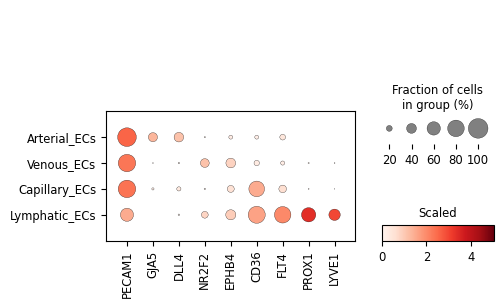

In [74]:
fig, ax = plt.subplots(figsize=[5, 3])
sc.pl.dotplot(endo_show, 
              var_names=marker_genes, 
              groupby='cst1',
              color_map='Reds',
              colorbar_title='Scaled',
              use_raw=False,      
              categories_order=[
                  'Arterial_ECs',
                  'Venous_ECs',
                  'Capillary_ECs',
                  'Lymphatic_ECs'],
              ax=ax, vmax=5
              )
fig.savefig('../figures/cst_characterization/ECs/dotplot_ECs.png', 
            dpi=300, bbox_inches='tight')

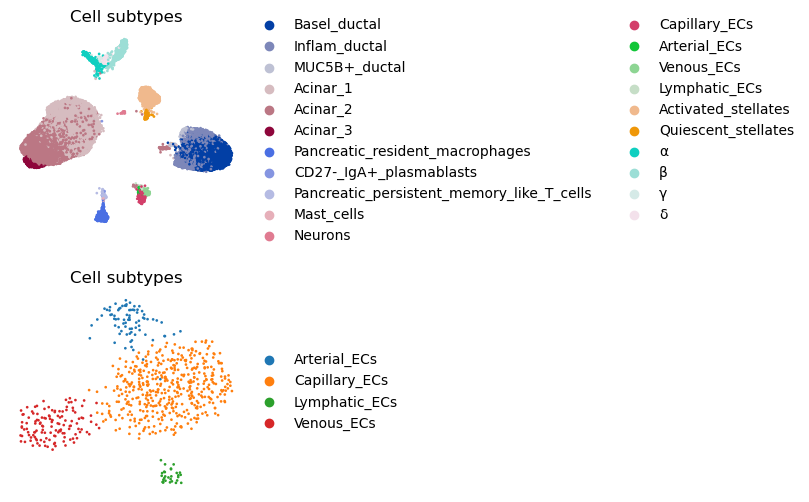

In [93]:
# glasbey_colors = sns.color_palette("tab20", acinar_abundance_pct_2.shape[0])

fig, axs = plt.subplots(2, 1, figsize=[3, 6])
plt.subplots_adjust(hspace=0.3)
sc.pl.umap(adata, color='cst1', ax=axs[0], size=15, show=False, 
           frameon=False, cmap='tab20')
axs[0].set_title('Cell subtypes')
sc.pl.umap(endo_new, color='cst1', ax=axs[1], size=15, show=False, frameon=False)
axs[1].set_title('Cell subtypes')
fig.savefig('../figures/cst_characterization/ECs/adata_UMAP.png', 
            dpi=300, bbox_inches='tight')

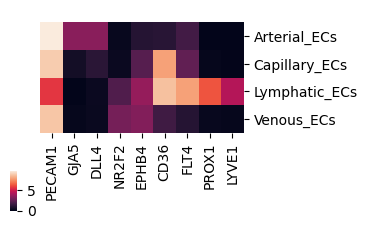

In [100]:
path = '../figures/cst_characterization/ECs/'
clustermap_maker_genes(endo_new, 'cst1', marker_genes, path, 
                       'heatmap_EC_marker_genes.png', 
                       col_cluster=False, 
                       row_cluster=False,
                      )

/tmp/ipykernel_2825/707077894.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acinar_abundance2 = acinar.obs[[cst_col, sample]].groupby([cst_col, sample]).size().unstack()


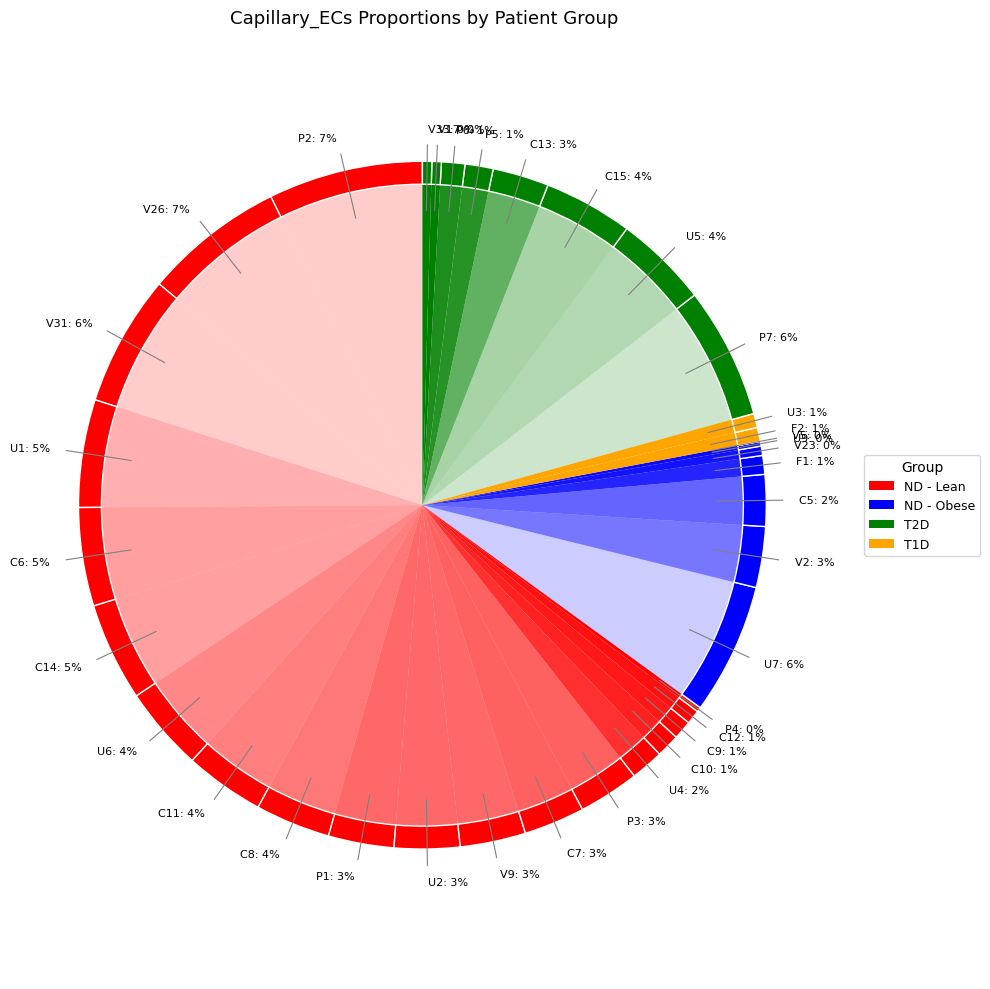

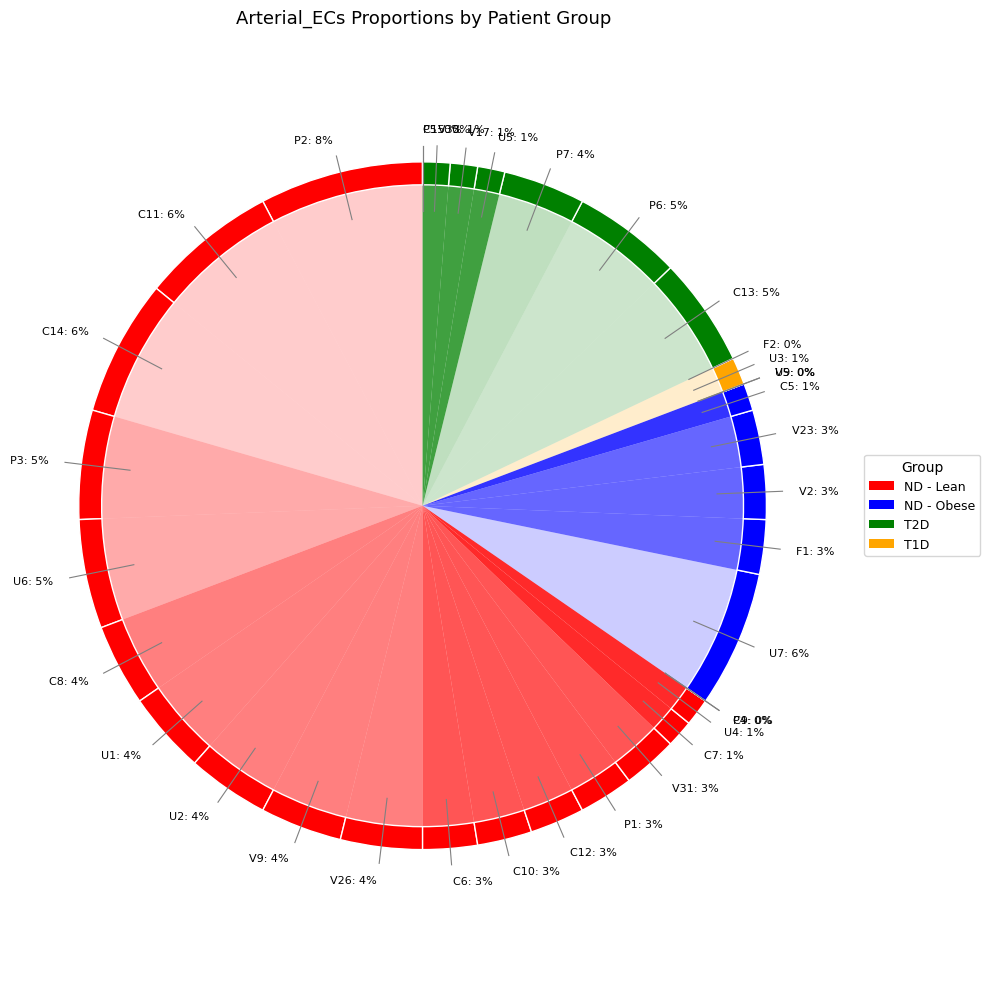

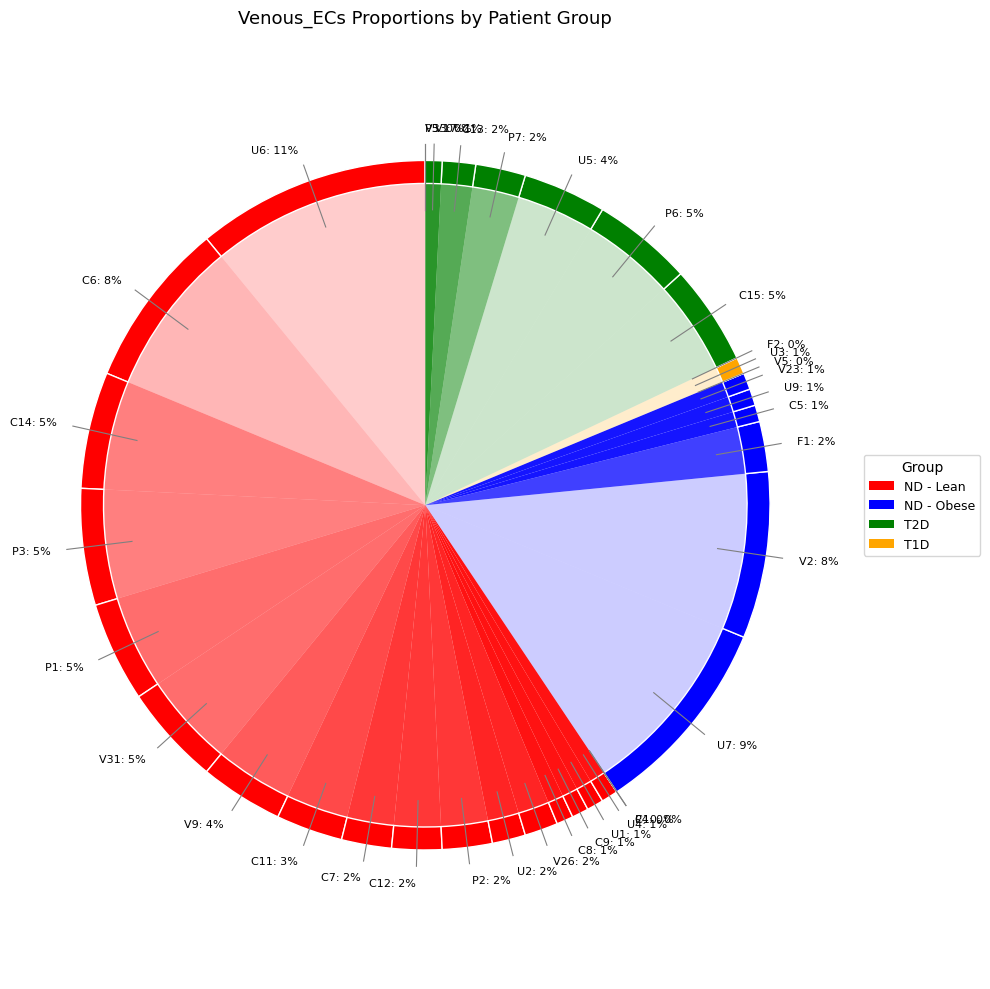

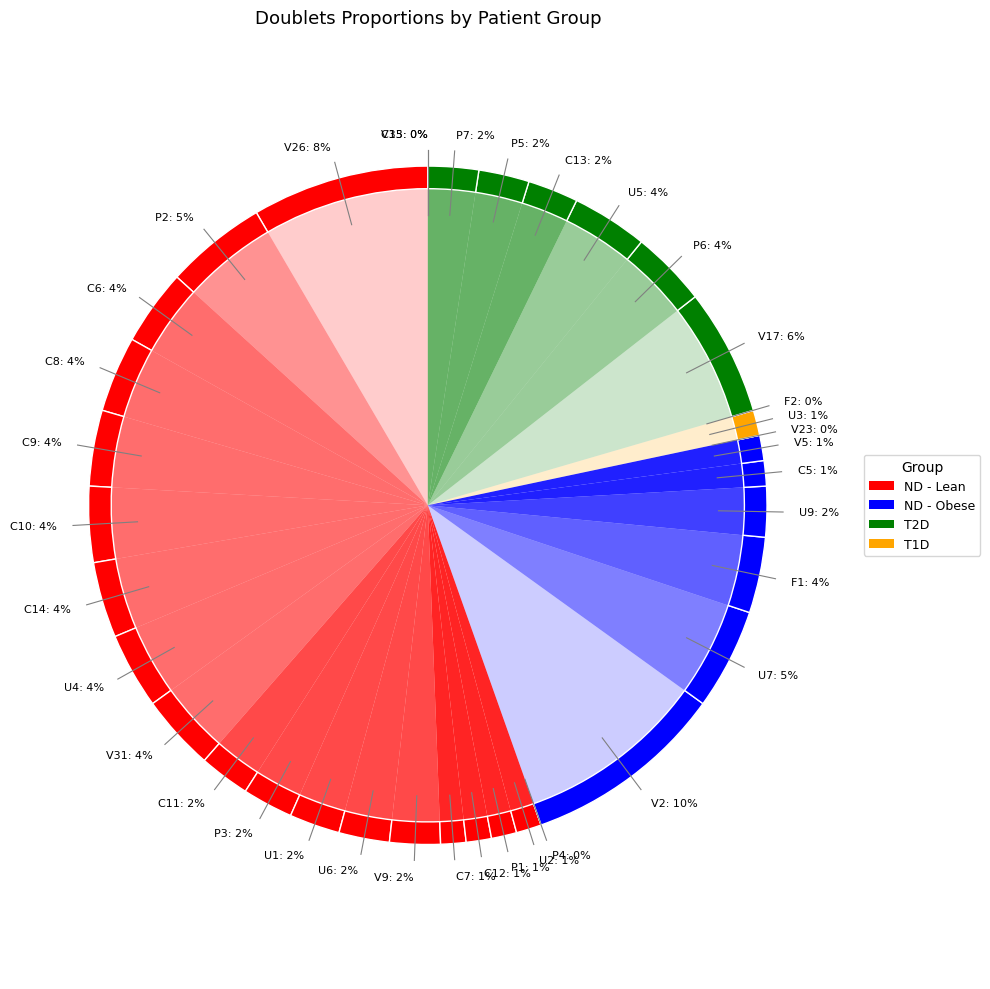

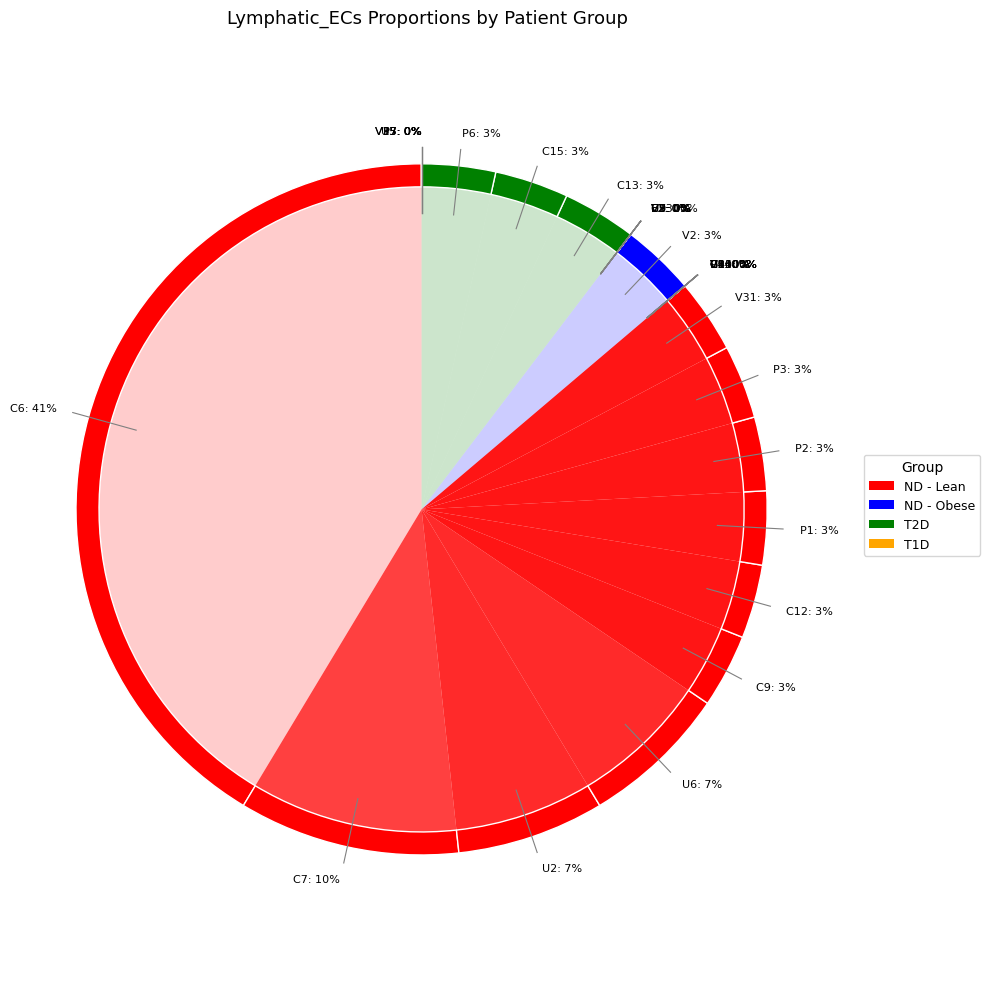

In [107]:
pie_plot_cst_abundace_by_sample(endo, 'cst1', 'sample', path)

/tmp/ipykernel_2825/1999673198.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acinar_abundance2 = adata.obs[[cst_col, 'sample']].groupby([cst_col, 'sample']).size().unstack()


{'fig': <Figure size 1000x300 with 1 Axes>,
 'ax': <Axes: ylabel='Proportion [%]'>}

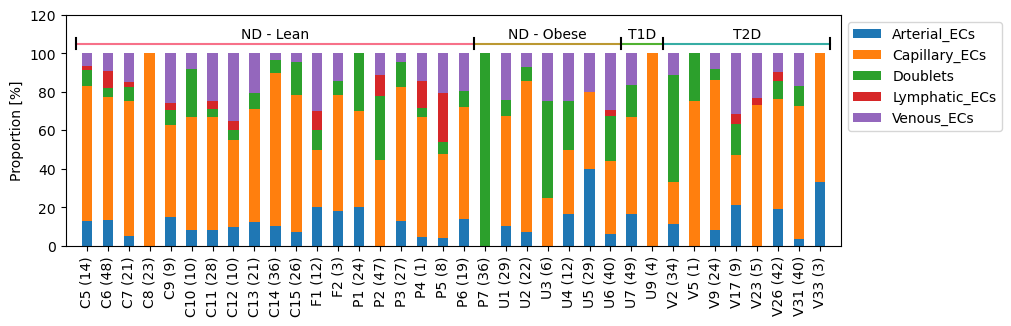

In [106]:
stacked_barplot_cst_abudance_by_sample(endo, 'cst1', metadata, path, 'Endothelial')

/tmp/ipykernel_2825/1999673198.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acinar_abundance2 = adata.obs[[cst_col, 'sample']].groupby([cst_col, 'sample']).size().unstack()


{'fig': <Figure size 1000x300 with 1 Axes>,
 'ax': <Axes: ylabel='Proportion [%]'>}

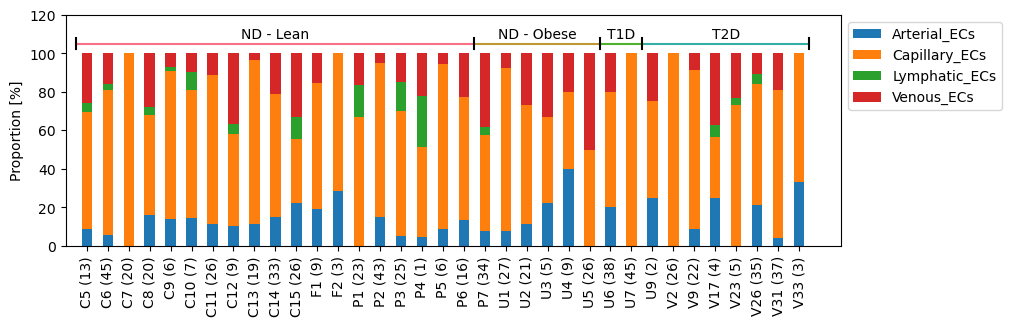

In [108]:
stacked_barplot_cst_abudance_by_sample(endo_new, 'cst1', metadata, path, 'Endothelial')

# Stellate cells

In [109]:
stellate = adata[adata.obs['cell_type'] == 'Stellate']

In [110]:
utils.normalizedata(stellate, log1p=True)

/home/yike/.conda/envs/scanpy/lib/python3.12/site-packages/scanpy/preprocessing/_normalization.py:207: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)


AnnData object with n_obs × n_vars = 1667 × 38560
    obs: 'sample', 'doublet_score', 'Sex', 'BMI', 'T1D', 'Diabetes Duration', 'T2D', 'HbA1c (%)', 'HbA1c', 'Age', 'CIT (hours)', 'Cohort', 'RIN', 'Nuclei isolation', 'group', 'cell_type', 'cell_subtype', 'cst1', 'cst2'
    var: 'n_counts', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'cst1_colors', 'log1p'
    obsm: 'X_pca', 'X_umap'

In [114]:
marker_genes = [
    'ACTA2',
    "COL6A3", # activated stellate
    "RGS5", # quiescent stellate  
]

In [115]:
stellate_show = stellate[:, marker_genes].copy()
sc.pp.scale(stellate_show, zero_center=False)

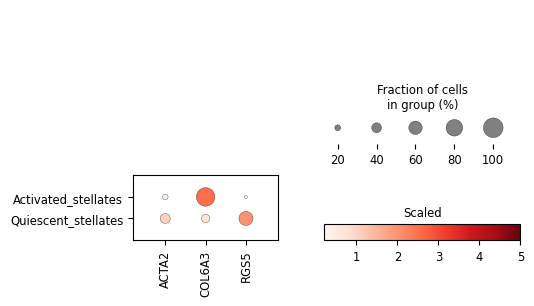

In [116]:
fig, ax = plt.subplots(figsize=[5, 3])
sc.pl.dotplot(stellate_show, 
              var_names=marker_genes, 
              groupby='cst1',
              color_map='Reds',
              colorbar_title='Scaled',
              use_raw=False,      
              ax=ax, vmax=5
              )
fig.savefig('../figures/cst_characterization/stellate/dotplot_stellate.png', 
            dpi=300, bbox_inches='tight')

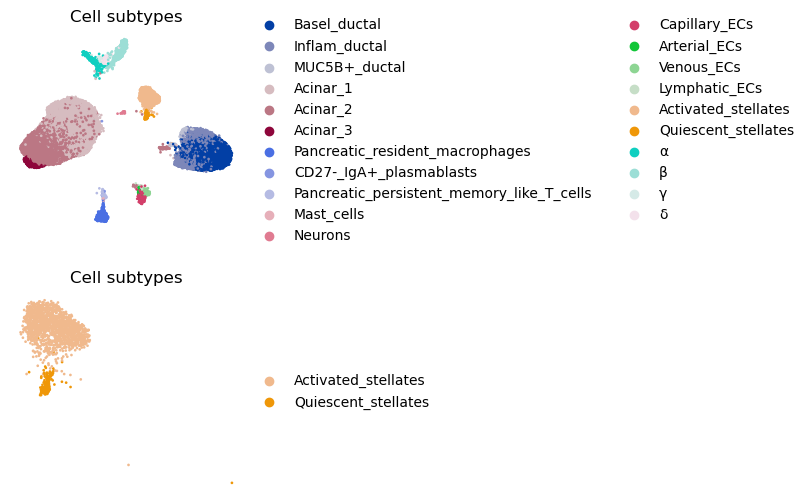

In [117]:
# glasbey_colors = sns.color_palette("tab20", acinar_abundance_pct_2.shape[0])

fig, axs = plt.subplots(2, 1, figsize=[3, 6])
plt.subplots_adjust(hspace=0.3)
sc.pl.umap(adata, color='cst1', ax=axs[0], size=15, show=False, 
           frameon=False, cmap='tab20')
axs[0].set_title('Cell subtypes')
sc.pl.umap(stellate, color='cst1', ax=axs[1], size=15, show=False, frameon=False)
axs[1].set_title('Cell subtypes')
fig.savefig('../figures/cst_characterization/stellate/adata_UMAP.png', 
            dpi=300, bbox_inches='tight')

/tmp/ipykernel_2825/707077894.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acinar_abundance2 = acinar.obs[[cst_col, sample]].groupby([cst_col, sample]).size().unstack()


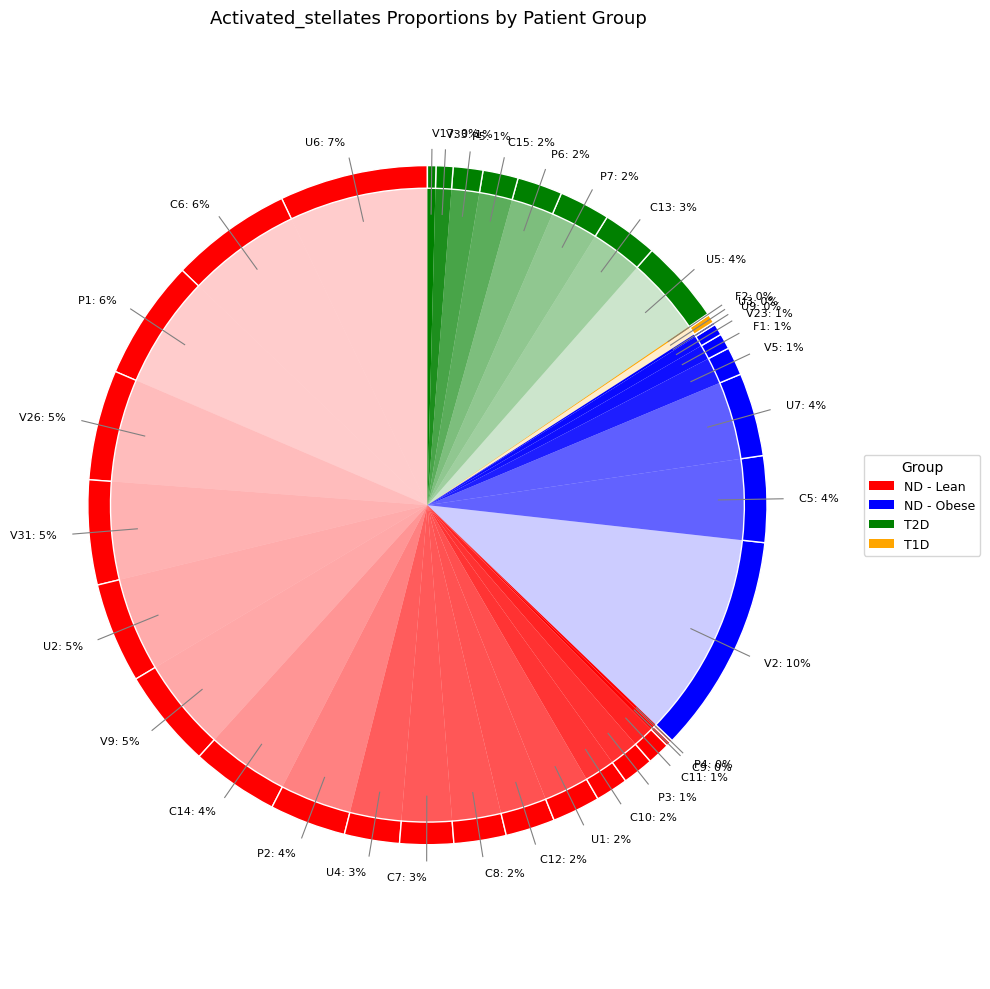

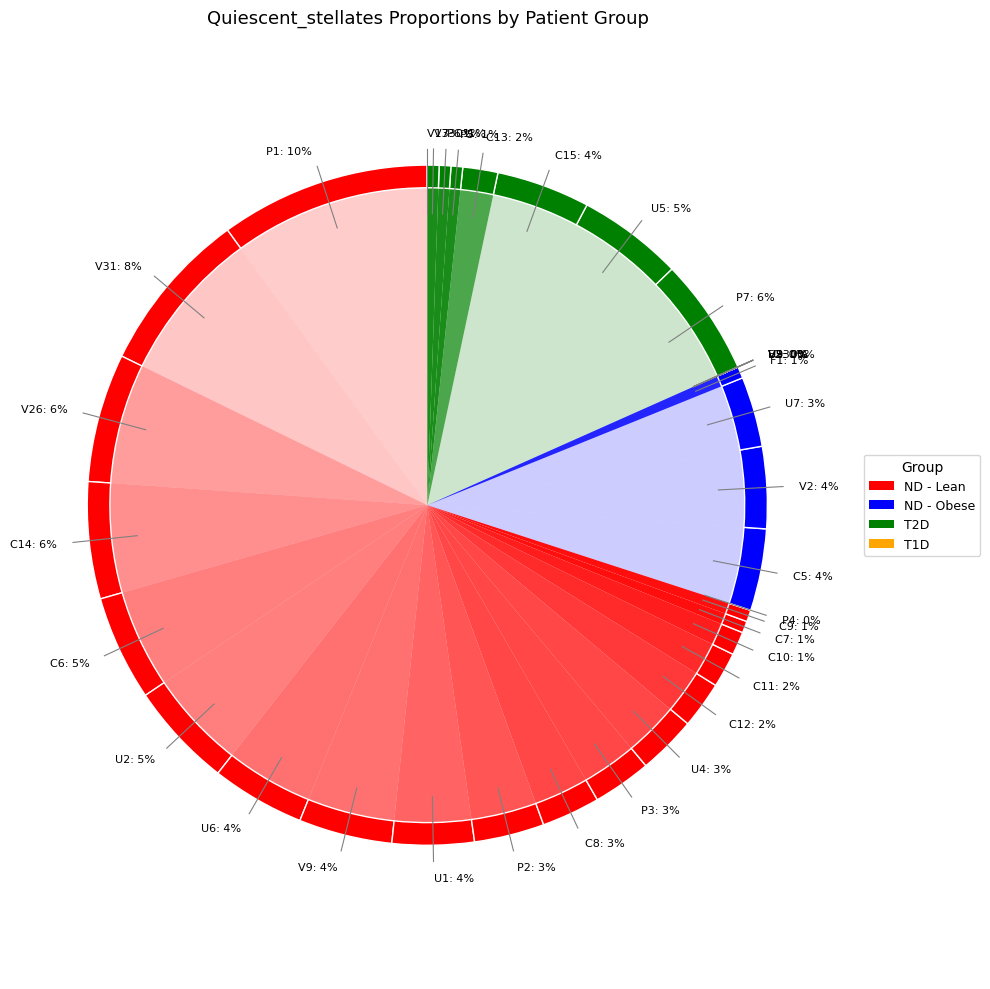

In [119]:
path = '../figures/cst_characterization/stellate/'
pie_plot_cst_abundace_by_sample(stellate, 'cst1', 'sample', path)

/tmp/ipykernel_2825/1999673198.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acinar_abundance2 = adata.obs[[cst_col, 'sample']].groupby([cst_col, 'sample']).size().unstack()


{'fig': <Figure size 1000x300 with 1 Axes>,
 'ax': <Axes: ylabel='Proportion [%]'>}

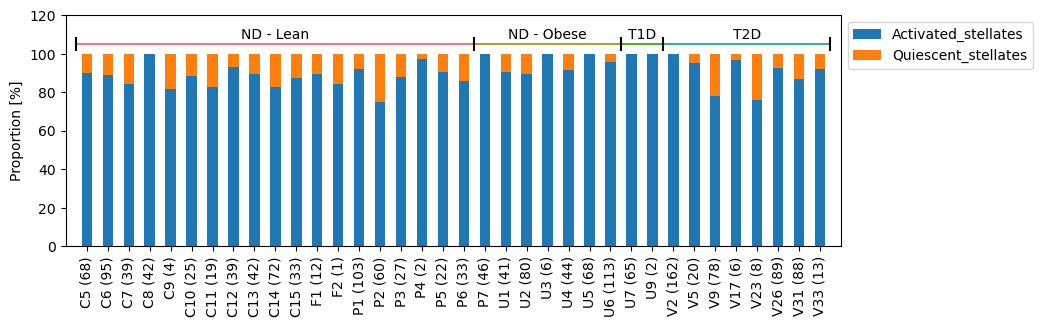

In [120]:
stacked_barplot_cst_abudance_by_sample(stellate, 'cst1', metadata, path, 'Stellate')

# endocrine cells

In [11]:
endocrine = adata[adata.obs['cell_type'] == 'Endocrine']

In [16]:
marker_genes = [
    "CHGA", # endocrine
    "GCG", "INS", "PPY", "SST", # endocrine
]

In [17]:
endocrine_show = endocrine[:, marker_genes].copy()
sc.pp.scale(endocrine_show, zero_center=False)

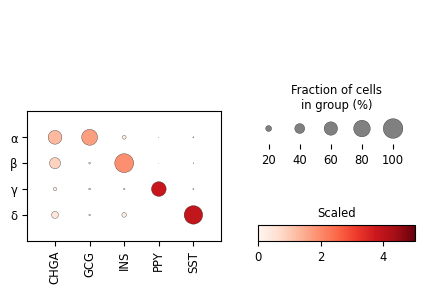

In [18]:
fig, ax = plt.subplots(figsize=[5, 3])
sc.pl.dotplot(endocrine_show, 
              var_names=marker_genes, 
              groupby='cst1',
              color_map='Reds',
              colorbar_title='Scaled',
              use_raw=False,      
              ax=ax, vmax=5
              )
fig.savefig('../figures/cst_characterization/Endocrine/dotplot_endocrine.png', 
            dpi=300, bbox_inches='tight')

/tmp/ipykernel_44094/707077894.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acinar_abundance2 = acinar.obs[[cst_col, sample]].groupby([cst_col, sample]).size().unstack()


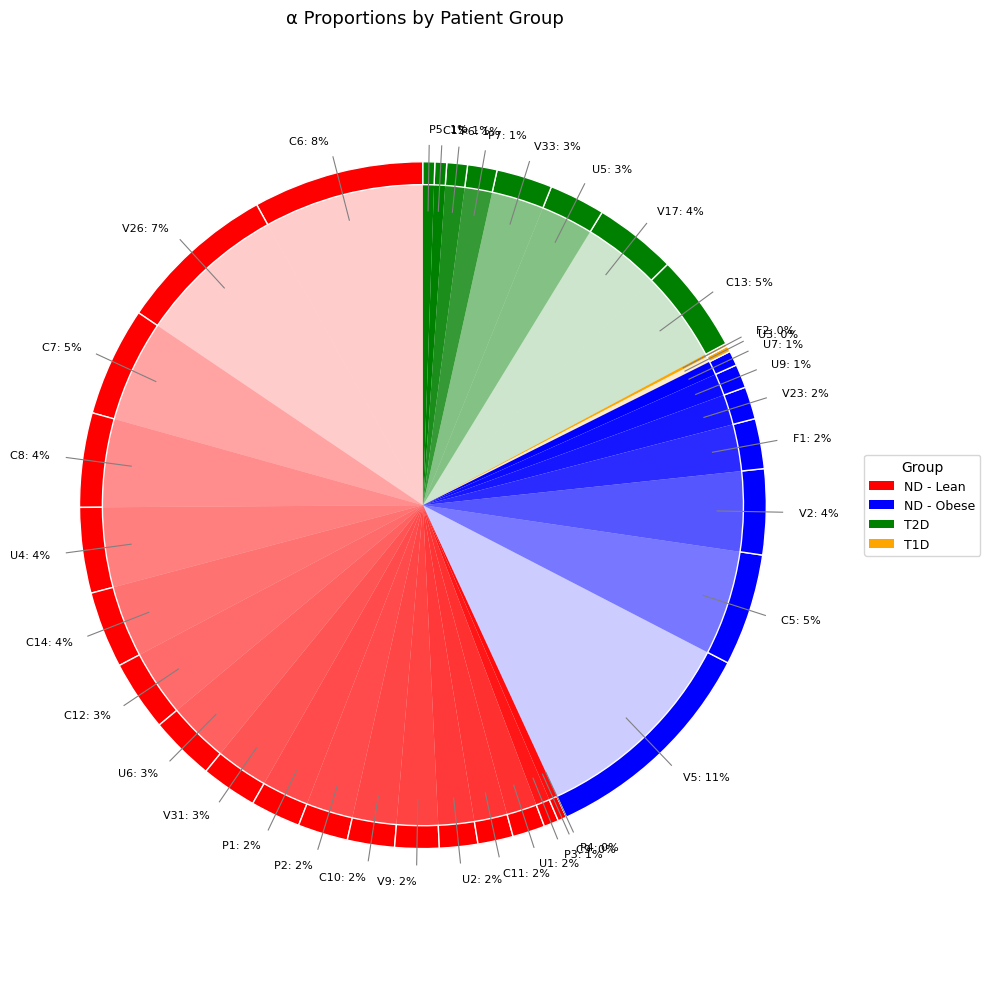

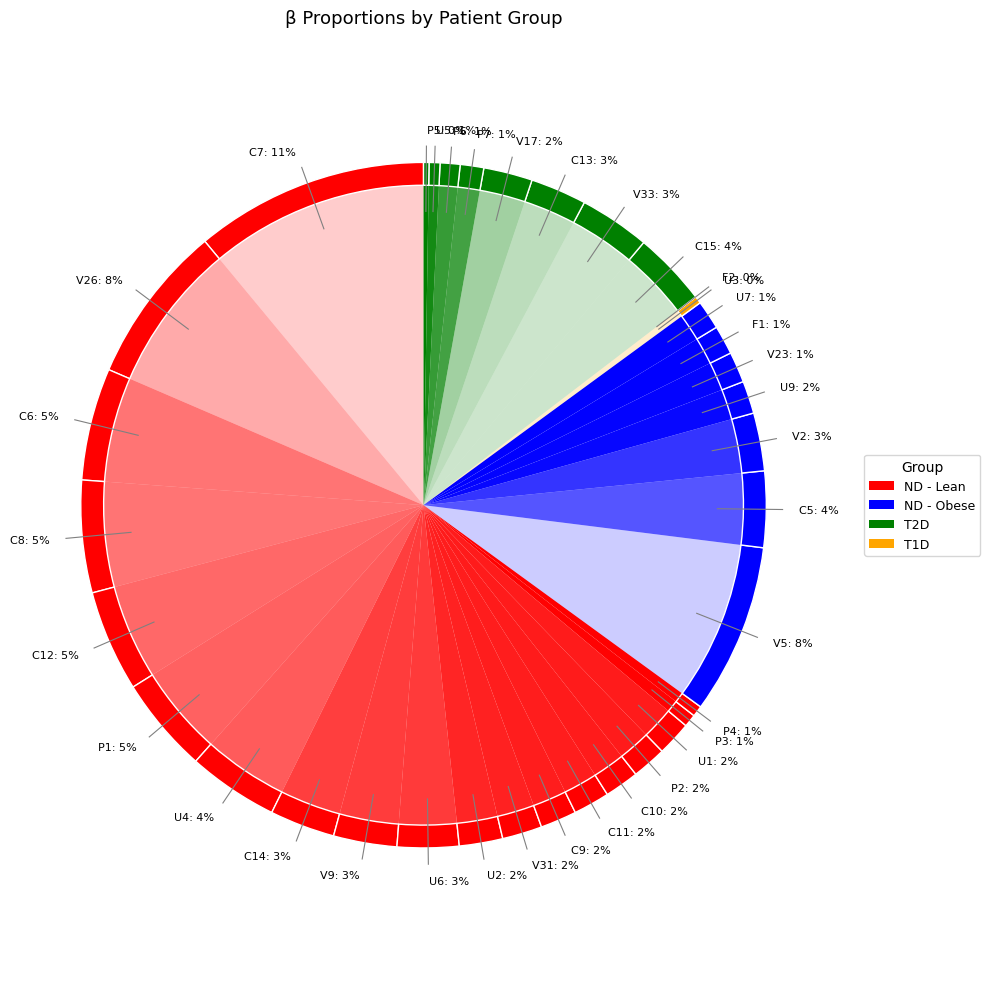

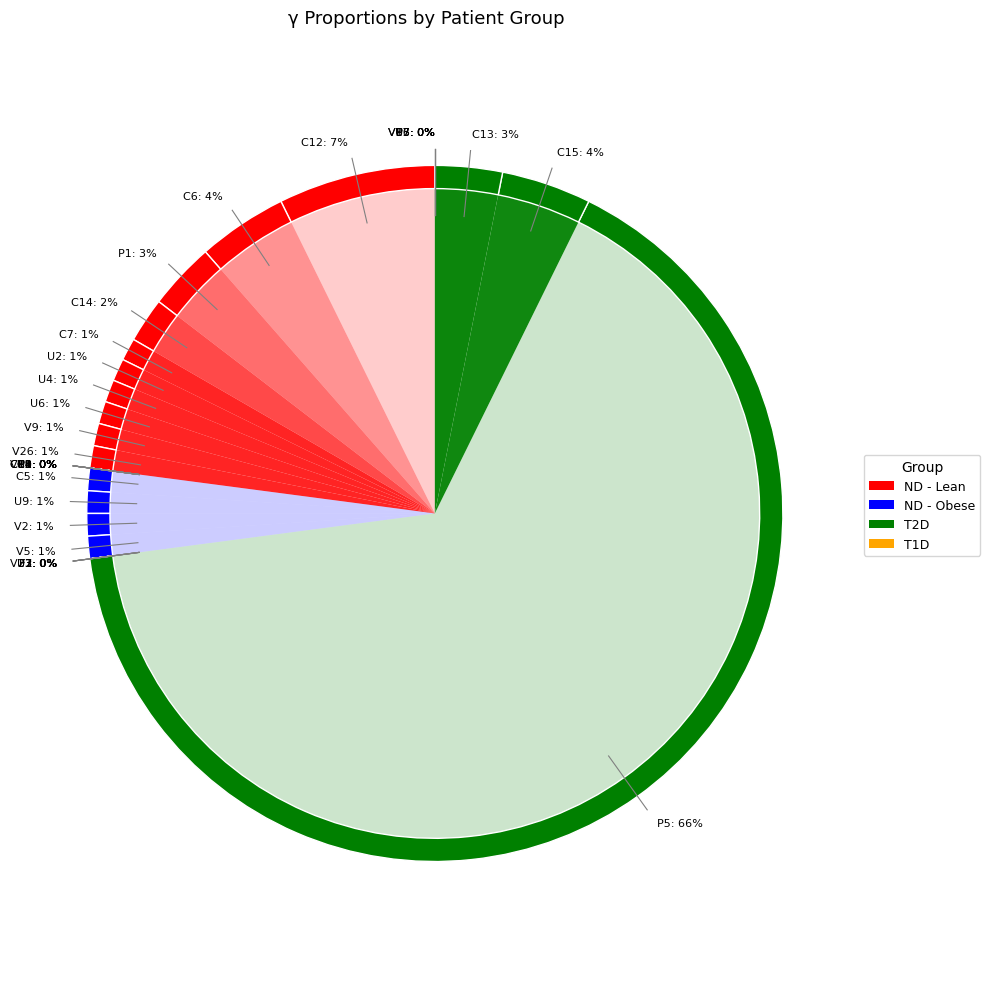

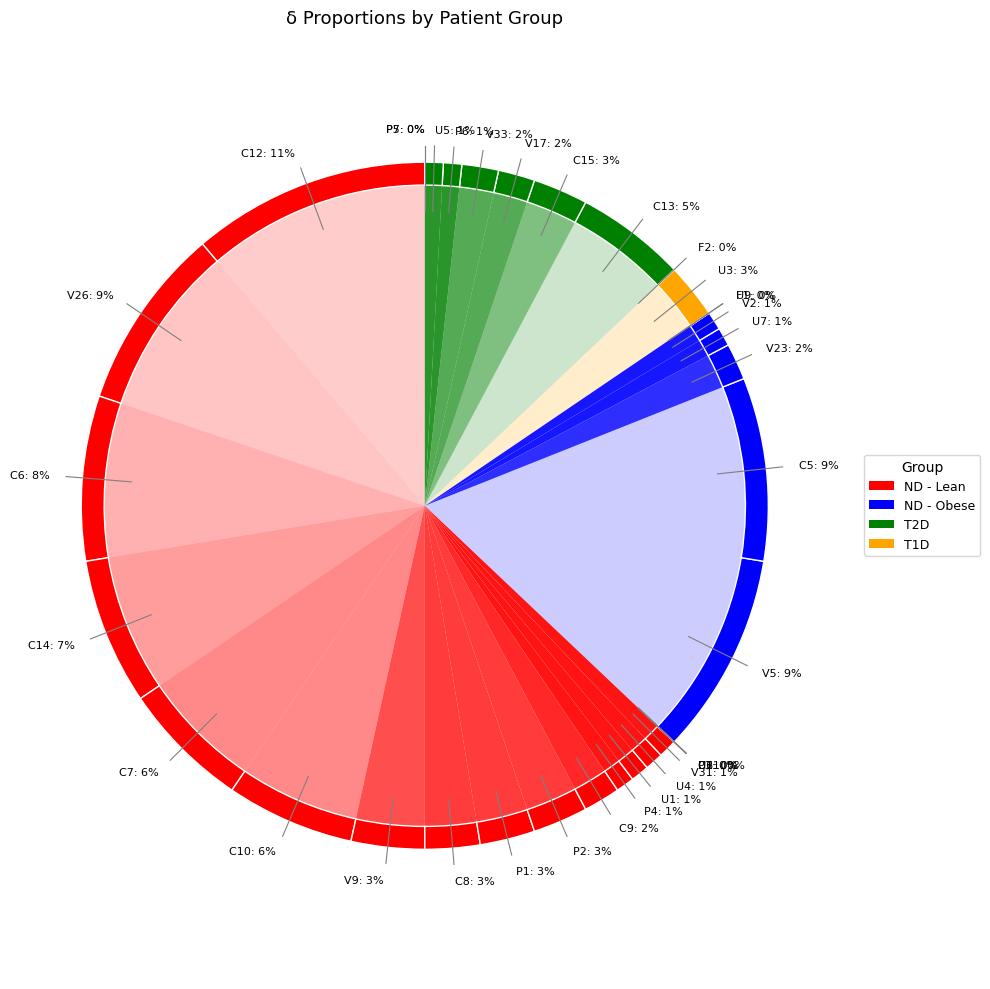

In [14]:
path = '../figures/cst_characterization/Endocrine/'
pie_plot_cst_abundace_by_sample(endocrine, 'cst1', 'sample', path)

/tmp/ipykernel_44094/1999673198.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  acinar_abundance2 = adata.obs[[cst_col, 'sample']].groupby([cst_col, 'sample']).size().unstack()


{'fig': <Figure size 1000x300 with 1 Axes>,
 'ax': <Axes: ylabel='Proportion [%]'>}

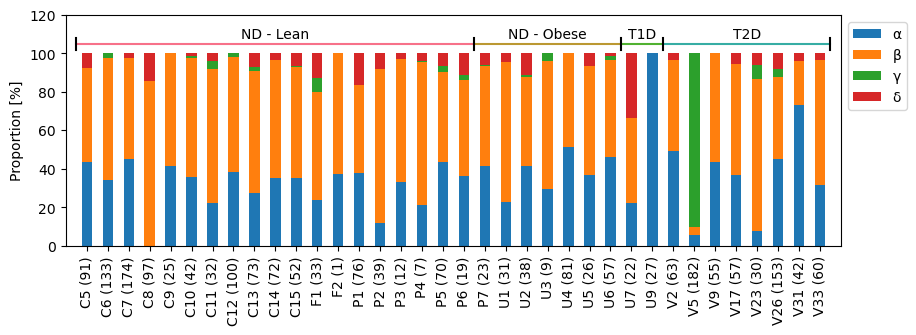

In [ ]:
stacked_barplot_cst_abudance_by_sample(endocrine, 'cst1', metadata, path, 'Endocrine')